In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Dataset 1 UVA.csv", sep=";")

In [3]:
df.head


<bound method NDFrame.head of                              id geslacht geboortedatum postcode woonplaats  \
0      5cb9a38136dd1336b9c528d1        m         0-0-0      NaN        NaN   
1      5cb9a38336dd1336b9c537f3        v         0-0-0      NaN        NaN   
2      5cb9a38236dd1336b9c52f07        m         0-0-0      NaN        NaN   
3      5cb9a38236dd1336b9c53694        v         0-0-0      NaN        NaN   
4      5cb9a38636dd1336b9c54e48        m         0-0-0      NaN        NaN   
...                         ...      ...           ...      ...        ...   
19995  5c6bed6d5798a7942837bfcd        m    19-09-1947  3815 MN        NaN   
19996  5c6bed715798a7942837dbb0        m    07-09-1986  7553 lg        NaN   
19997  5c6bed725798a7942837e588        m           NaN   2412vf        NaN   
19998  5c6bed6b5798a7942837b3c3        m    15-03-1945  5632 PM        NaN   
19999  5c6bed715798a7942837dd89        v    27-03-1997  6721 GV        NaN   

                                 

In [4]:
df['geboortedatum'] = df['geboortedatum'].replace(
    ['0', '0-0-0', '0000-00-00'],
    pd.NA
)

In [5]:
df['geboortedatum'].isna().mean() * 100

39.96

In [6]:
df.head

<bound method NDFrame.head of                              id geslacht geboortedatum postcode woonplaats  \
0      5cb9a38136dd1336b9c528d1        m          <NA>      NaN        NaN   
1      5cb9a38336dd1336b9c537f3        v          <NA>      NaN        NaN   
2      5cb9a38236dd1336b9c52f07        m          <NA>      NaN        NaN   
3      5cb9a38236dd1336b9c53694        v          <NA>      NaN        NaN   
4      5cb9a38636dd1336b9c54e48        m          <NA>      NaN        NaN   
...                         ...      ...           ...      ...        ...   
19995  5c6bed6d5798a7942837bfcd        m    19-09-1947  3815 MN        NaN   
19996  5c6bed715798a7942837dbb0        m    07-09-1986  7553 lg        NaN   
19997  5c6bed725798a7942837e588        m           NaN   2412vf        NaN   
19998  5c6bed6b5798a7942837b3c3        m    15-03-1945  5632 PM        NaN   
19999  5c6bed715798a7942837dd89        v    27-03-1997  6721 GV        NaN   

                                 

In [7]:
df = df.rename(columns={
    'geslacht': 'gender',
    'geboortedatum': 'birth_date',
    'postcode': 'postcode',
    'woonplaats': 'city',
    'interesses': 'interests'
})

Gender analysis

In [8]:
df['gender'].value_counts(dropna=False)

gender
v          11018
m           8493
o            409
Mevrouw       57
De Heer       23
Name: count, dtype: int64

In [9]:
df['gender'] = df['gender'].str.strip().str.lower()

df['gender'] = df['gender'].replace({
    'v': 'female',
    'mevrouw': 'female',
    'm': 'male',
    'de heer': 'male',
    'o': 'other'
})

In [10]:
df['gender'].value_counts(dropna=False)

gender
female    11075
male       8516
other       409
Name: count, dtype: int64

In [11]:
df['gender'].value_counts(normalize=True)

gender
female    0.55375
male      0.42580
other     0.02045
Name: proportion, dtype: float64

In [12]:
from datetime import datetime

df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')
today = pd.to_datetime('today')

df['age'] = (today - df['birth_date']).dt.days // 365

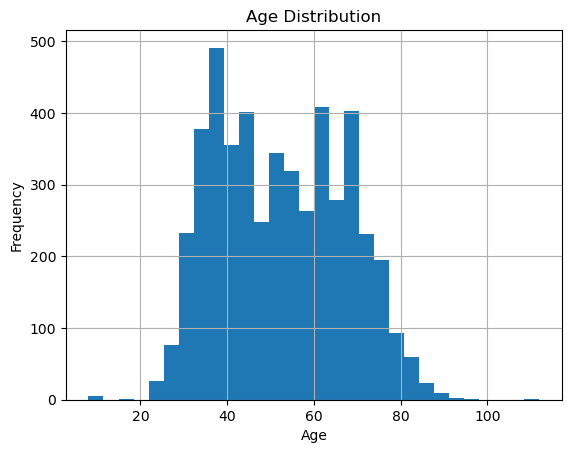

In [13]:
import matplotlib.pyplot as plt

df['age'].dropna().hist(bins=30)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

In [14]:
df_interests = df.copy()

df_interests['interests'] = df_interests['interests'].str.split(',')
df_interests = df_interests.explode('interests')

In [15]:
df_interests['interests'] = (
    df_interests['interests']
    .str.strip()
    .str.lower()
)

Unique interests

In [16]:
df_interests['interests'].nunique()

60

In [17]:
df_interests['interests'].unique()

array(['energie', 'loterij', 'kranten', 'entertainment', 'winactie',
       'cadeau', 'bladen', 'kansspelen', 'goededoelen', 'acties',
       'unknown', 'kortingen', 'onderzoek', 'auto', 'cx80', 'mkb',
       'verzekering', 'auto inruilen', 'mazda', 'elektrisch',
       'zakelijk rijden', 'audi', 'mazda6e', 'ondernemers', 'dacia',
       'bigevent', 'hybrid', 'mercedes', 'toyota', 'lease', 'windows',
       'bank', 'beleggen', 'finance', 'cx60', 'hr', 'cx5', 'bedrijven',
       'it', 'telcom', 'hypotheek', 'centraal beheer', 'mx30', 'cx30',
       'ios', 'android', 'hyundai', 'linux', nan, 'bedrijfswagen',
       'belastingdienst', 'wetgeving', 'zzp', 'zorg', 'overheid',
       'bezorgmaaltijden', 'horeca', 'os x', 'porsche', 'chrome os',
       'mac os'], dtype=object)

In [18]:
df_interests['interests'].value_counts()

interests
bladen              19382
acties              18990
kranten             18536
winactie            17859
cadeau              17491
kortingen           17436
energie             16884
goededoelen         15515
onderzoek           15224
auto                12766
mazda               12091
unknown             12074
lease               12066
zakelijk rijden     12012
elektrisch          11821
auto inruilen       10336
kansspelen          10224
toyota               9783
audi                 9715
dacia                8440
bigevent             8440
entertainment        8375
finance              8102
bank                 7626
beleggen             7519
verzekering          6966
cx60                 6876
loterij              6827
mkb                  6698
ondernemers          6008
cx80                 5558
hybrid               4867
mazda6e              4601
cx30                 3138
mercedes             2868
bedrijven            2644
mx30                 2609
cx5                  2609
wi

In [19]:
df['postcode'] = (
    df['postcode']
    .astype(str)
    .str.upper()
    .str.replace(' ', '', regex=False)
    .str.extract(r'(\d{4}[A-Z]{0,2})')
)

In [20]:
df['postcode'].sample(50)

2421        NaN
19422    8244BT
12491    3207HN
17721       NaN
18884       NaN
2004        NaN
11023    3238XN
17070       NaN
11928    3543DD
7112     8900AA
11994    7433CV
11489    4827NL
6817     3443TJ
10179    9742KW
16917       NaN
3463        NaN
3054        NaN
7820     1422WS
5005       2315
13751       NaN
5031        NaN
18186       NaN
4872        NaN
6883     6835CC
6256       2040
8783       3530
7319     5482HD
14705    2718GD
15243    7007KT
15002    3401AV
18070       NaN
5303       9310
6038     6214VM
8489       8870
16693       NaN
11676    1335RB
5506        NaN
3498        NaN
10735    8531MG
17287       NaN
5948     4931VG
9691     1541AG
3092        NaN
273         NaN
7310       8582
16451       NaN
13993       NaN
1874        NaN
17162       NaN
9043     1107AE
Name: postcode, dtype: object

In [21]:
df['city'] = (
    df['city']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace('null', pd.NA)
)

In [22]:
df['city'] = df['city'].replace('nan', pd.NA)

In [23]:
df['interests'] = df['interests'].str.split(',')

In [24]:
type(df['interests'].iloc[0])

list

In [25]:
df['interests'] = df['interests'].apply(
    lambda x: [i.strip().lower() for i in x] if isinstance(x, list) else []
)

In [26]:
df['n_interests'] = df['interests'].apply(len)

In [27]:
df.head

<bound method NDFrame.head of                              id  gender birth_date postcode  city  \
0      5cb9a38136dd1336b9c528d1    male        NaT      NaN  <NA>   
1      5cb9a38336dd1336b9c537f3  female        NaT      NaN  <NA>   
2      5cb9a38236dd1336b9c52f07    male        NaT      NaN  <NA>   
3      5cb9a38236dd1336b9c53694  female        NaT      NaN  <NA>   
4      5cb9a38636dd1336b9c54e48    male        NaT      NaN  <NA>   
...                         ...     ...        ...      ...   ...   
19995  5c6bed6d5798a7942837bfcd    male        NaT   3815MN  <NA>   
19996  5c6bed715798a7942837dbb0    male 1986-07-09   7553LG  <NA>   
19997  5c6bed725798a7942837e588    male        NaT   2412VF  <NA>   
19998  5c6bed6b5798a7942837b3c3    male        NaT   5632PM  <NA>   
19999  5c6bed715798a7942837dd89  female        NaT   6721GV  <NA>   

                                                mailings  \
0      1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:82...   
1      1:668,1:692,1:

# ANALYSIS

## Campaign

### Data prep

In [28]:
# inspect (in)valid values in opens and clicks
import re

def classify_value(x):
    if pd.isna(x) or str(x).strip() == '':
        return 'missing'
    
    x = str(x).strip()

    # valid id
    if re.search(r'\b1:\d{3,4}\b', x):
        return 'id_format'
    
    return 'non_id_format'

In [29]:
df['open_type'] = df['opens'].apply(classify_value)
df['click_type'] = df['clicks'].apply(classify_value)

print(df['open_type'].value_counts())
print(df['click_type'].value_counts())

open_type
id_format        17793
non_id_format     2037
missing            170
Name: count, dtype: int64
click_type
missing          19019
non_id_format      787
id_format          194
Name: count, dtype: int64


In [30]:
print(df['mailings'].iloc[0])

# function to extract id from mailings, opens, clicks
def extract_ids(text):
    if pd.isna(text):
        return []
    items = text.split(',')
    ids = []

    for item in items:
        item = item.strip()
        if ':' in item:
            ids.append(int(item.split(':')[1]))
    
    return ids

1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:825,1:846,1:859,1:866,1:873,1:876,1:879,1:892,1:891,1:899,1:874,1:920,1:906,1:913,1:930,1:935,1:958,1:996,1:1031,1:1007,1:1013,1:1040,1:1057,1:1084,1:1093,1:1122,1:1146,1:1159,1:1177,1:1178,1:1231,1:1237,1:1245,1:1281,1:1297,1:1314,1:1340,1:1346,1:1334,1:1362,1:1382,1:1390,1:1398,1:1417


In [31]:
# parse mailings, open, clicks
df['mailing_ids'] = df['mailings'].apply(extract_ids)
df['open_ids'] = df.apply(
    lambda row: extract_ids(row['opens']) if row['open_type'] == 'id_format' else [],
    axis = 1)
df['click_ids'] = df.apply(
    lambda row: extract_ids(row['clicks']) if row['click_type'] == 'id_format' else [],
    axis = 1)

In [32]:
df[['opens', 'open_type', 'open_ids', 'clicks', 'click_type', 'click_ids']].head(26)

,opens,open_type,open_ids,clicks,click_type,click_ids
0,"1:879,1:891,1:913,1:935,1:996,1:1031,1:1007,1:...",id_format,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",NaN,missing,[]
1,"1:668,1:692,1:714,1:733,1:753,1:777,1:770,1:75...",id_format,"[668, 692, 714, 733, 753, 777, 770, 758, 760, ...",NaN,missing,[]
2,"1:876,1:961,1:1159",id_format,"[876, 961, 1159]",NaN,missing,[]
3,"1:654,1:706,1:733,1:831,1:866,1:876,1:891,1:91...",id_format,"[654, 706, 733, 831, 866, 876, 891, 913, 961, ...",NaN,missing,[]
4,"1:668,1:692,1:714,1:760,1:785,1:804,1:825,1:84...",id_format,"[668, 692, 714, 760, 785, 804, 825, 846, 873, ...",NaN,missing,[]
5,"1:876,1:882,1:892,1:874,1:920,1:906,1:961,1:97...",id_format,"[876, 882, 892, 874, 920, 906, 961, 970, 1003,...",NaN,missing,[]
6,"1:714,1:733,1:777,1:770,1:758,1:785,1:803,1:85...",id_format,"[714, 733, 777, 770, 758, 785, 803, 859, 876, ...",NaN,missing,[]
7,"1:876,1:879,1:892,1:891,1:874,1:920,1:906,1:91...",id_format,"[876, 879, 892, 891, 874, 920, 906, 913, 932, ...",NaN,missing,[]
8,"1:668,1:692,1:714,1:760,1:785,1:824,1:846,1:85...",id_format,"[668, 692, 714, 760, 785, 824, 846, 859, 866, ...",NaN,missing,[]
9,"1:761,1:913,1:1381,1:1391",id_format,"[761, 913, 1381, 1391]",NaN,missing,[]


In [33]:
# rename column id
df = df.rename(columns = {'id': 'user_id'})

In [34]:
# explode dataset
df_exploded = df.explode('mailing_ids')
df_exploded = df_exploded.rename(columns = {'mailing_ids': 'mailing_id'})

df_exploded[['user_id', 'mailing_id']].head()

,user_id,mailing_id
0,5cb9a38136dd1336b9c528d1,668
0,5cb9a38136dd1336b9c528d1,692
0,5cb9a38136dd1336b9c528d1,714
0,5cb9a38136dd1336b9c528d1,733
0,5cb9a38136dd1336b9c528d1,761


In [35]:
import numpy as np

In [36]:
# create three state open column: 1 if mailing_id was opened, 0 if not opened, NaN if invalid
def check_open(row):
    if row['open_type'] == 'missing':
        return 0
    
    if row['open_type'] != 'id_format':
        return np.nan
    
    if row['mailing_id'] in row['open_ids']:
        return 1
    else:
        return 0
    
df_exploded['open'] = df_exploded.apply(check_open, axis=1)

df_exploded[['user_id', 'mailing_id', 'open', 'open_ids']].head()

,user_id,mailing_id,open,open_ids
0,5cb9a38136dd1336b9c528d1,668,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."
0,5cb9a38136dd1336b9c528d1,692,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."
0,5cb9a38136dd1336b9c528d1,714,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."
0,5cb9a38136dd1336b9c528d1,733,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."
0,5cb9a38136dd1336b9c528d1,761,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."


In [37]:
# create three state click column
def check_click(row):
    if row['click_type'] == 'missing':
        return 0
    
    if row['click_type'] != 'id_format':
        return np.nan
    
    if row['mailing_id'] in row['click_ids']:
        return 1
    else:
        return 0
    
df_exploded['click'] = df_exploded.apply(check_click, axis=1)

df_exploded[['user_id', 'mailing_id', 'open', 'click', 'open_ids', 'click_ids']].head()

,user_id,mailing_id,open,click,open_ids,click_ids
0,5cb9a38136dd1336b9c528d1,668,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]
0,5cb9a38136dd1336b9c528d1,692,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]
0,5cb9a38136dd1336b9c528d1,714,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]
0,5cb9a38136dd1336b9c528d1,733,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]
0,5cb9a38136dd1336b9c528d1,761,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]


In [38]:
df_exploded[['user_id', 'mailing_id', 'open', 'click']].head()

,user_id,mailing_id,open,click
0,5cb9a38136dd1336b9c528d1,668,0.0,0.0
0,5cb9a38136dd1336b9c528d1,692,0.0,0.0
0,5cb9a38136dd1336b9c528d1,714,0.0,0.0
0,5cb9a38136dd1336b9c528d1,733,0.0,0.0
0,5cb9a38136dd1336b9c528d1,761,0.0,0.0


In [39]:
print(df_exploded['open'].value_counts(dropna = False))
print(df_exploded['click'].value_counts(dropna = False))

open
1.0    567034
0.0    490510
NaN     98760
Name: count, dtype: int64
click
0.0    1103047
NaN      52062
1.0       1195
Name: count, dtype: int64


In [40]:
# load dataset 2
df2 = pd.read_excel('DATSET 2 UVA lijst mailings.xlsx')

In [41]:
# rename columns
df2 = df2.rename(columns = {
    'ID': 'mailing_id',
    'Mailing': 'mailing_info',
    'Subjectline': 'subject_line',
    'Preheader': 'preheader'
})

In [42]:
# merge dataset 1 and dataset 2
df_final = df_exploded.merge(
    df2,
    on = 'mailing_id',
    how = 'left'
)

In [43]:
df_final[['user_id', 'mailing_id', 'open', 'click', 'subject_line']].head()

,user_id,mailing_id,open,click,subject_line
0,5cb9a38136dd1336b9c528d1,668,0.0,0.0,"Lezen, puzzelen, genieten: 4 edities cadeau"
1,5cb9a38136dd1336b9c528d1,692,0.0,0.0,4 weken jouw favoriete krant digitaal voor maa...
2,5cb9a38136dd1336b9c528d1,714,0.0,0.0,Profiteer nu: €300 bonus én vaste energietarieven
3,5cb9a38136dd1336b9c528d1,733,0.0,0.0,Jouw mening is geld waard – start vandaag nog
4,5cb9a38136dd1336b9c528d1,761,0.0,0.0,Speel mee met de ENGIE woordlegger!


In [44]:
# drop unnecessary columns
df_final = df_final.drop(columns = [
    'mailings',
    'opens',
    'clicks',
    'open_ids',
    'click_ids'
])

In [45]:
print(df_final.columns)
df_final.head()

Index(['user_id', 'gender', 'birth_date', 'postcode', 'city', 'interests',
       'age', 'n_interests', 'open_type', 'click_type', 'mailing_id', 'open',
       'click', 'mailing_info', 'subject_line', 'preheader'],
      dtype='object')


,user_id,gender,birth_date,postcode,city,interests,age,n_interests,open_type,click_type,mailing_id,open,click,mailing_info,subject_line,preheader
0,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,668,0.0,0.0,2025/04/24 CPX - MM MAX Magazine - 4 gratis nrs,"Lezen, puzzelen, genieten: 4 edities cadeau","Vraag nu aan – geen kosten, geen verplichtingen."
1,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,692,0.0,0.0,2025/05/29 DPG 4W1E,4 weken jouw favoriete krant digitaal voor maa...,"Toegang tot AD, de Volkskrant, Trouw en meer v..."
2,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,714,0.0,0.0,2025/05/06 CPX - MM - ENGIE BONUS,Profiteer nu: €300 bonus én vaste energietarieven,ENGIE helpt je graag met persoonlijk advies.
3,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,733,0.0,0.0,2025/05/14 LIFEPOINTS,Jouw mening is geld waard – start vandaag nog,Verdien punten voor digitale cadeaubonnen zoal...
4,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,761,0.0,0.0,2025/05/27 CPX - MM - ENGIE,Speel mee met de ENGIE woordlegger!,"En win een solar powerbank t.w.v. €79,95."


In [46]:
df_final.shape

(1156304, 16)

In [47]:
emails_per_user = df_final.groupby('user_id')[['mailing_id']].count()
emails_per_user.describe()

,mailing_id
count,20000.000000
mean,57.815200
std,21.067557
min,8.000000
25%,47.000000
50%,60.000000
75%,72.000000
max,120.000000


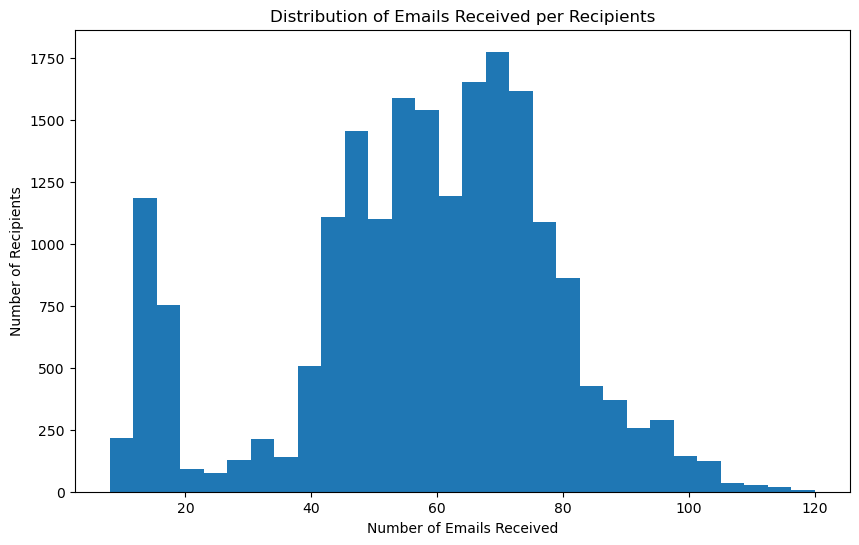

In [48]:
plt.figure(figsize=(10,6))

plt.hist(
    emails_per_user,
    bins=30
)

plt.title('Distribution of Emails Received per Recipients')
plt.xlabel('Number of Emails Received')
plt.ylabel('Number of Recipients')

plt.show()

In [49]:
df_final[['open']].sum()

open    567034.0
dtype: float64

### Overall engagement rates

In [50]:
# subjecline effectiveness (known cases only)
print('Open rate:', df_final['open'].mean())

# content effectiveness (known cases only)
print('Click rate:', df_final['click'].mean())

Open rate: 0.5361800549197008
Click rate: 0.001082190316977619


In [51]:
print('Open unknown %:', df_final['open'].isna().mean())
print('Click unknown %:', df_final['click'].isna().mean())

Open unknown %: 0.08541006517317246
Click unknown %: 0.045024491829138355


In [52]:
# subjectline

result = df_final.groupby(['subject_line', 'preheader']).agg(
    open_mean = ('open', 'mean'),
    click_mean = ('click', 'mean'),
    count_valid = ('open', 'count'),    #excludes NaN
    count_total = ('open', 'size')      #includes everything
)

# top subjectline being sent
result.sort_values('count_valid', ascending = False)[
    ['count_valid', 'count_total', 'open_mean', 'click_mean']
].head(10)

,,count_valid,count_total,open_mean,click_mean
subject_line,preheader,,,,
MAX Magazine én een HEMA verrassing voor jou!,Een jaar lang MAX Magazine én een HEMA giftcard t.w.v. €10.-.,32118,35396,0.496793,0.000383
Ontvang 4 nummers van MAX Magazine cadeau!,Maak kennis met het grootste lifestyle magazine van Nederland.,24601,26489,0.687655,0.000508
Krijg VROUW Glossy of Privé bij De Telegraaf,"Kies uw extraatje en lees De Telegraaf vanaf 5,19 euro per week.",19171,21351,0.644776,0.000778
Wat zit er in Donalds strandtas?,Ontdek het pakket en lees de leukste avonturen deze zomer.,18304,20372,0.000000,0.000000
Meer weten over de impact van Hulphond Nederland?,"Ontvang inspirerende verhalen én maak kans op een cadeaubon van €25,-.",17562,18729,0.638936,0.000337
Welke deal past bij jou deze week?,"Van 4 weken gratis lezen tot een proefabonnement voor 8,-.",17493,19360,0.513405,0.000753
Laatste kans: 4 weken jouw krant voor 1 euro p/w,"Lees o.a. Het AD, de Volkskrant en Trouw. Mis het niet.",17210,19195,0.476351,0.000163
Kies en lees: 4 weken de krant voor 1 euro p/w,Gratis toegang tot digitale artikelen inbegrepen.,16982,18808,0.517195,0.000387
Jouw huidige auto is meer waard dan je denkt,Ontdek het met het Mazda Taxatie Festival.,16534,16974,0.554857,0.003699


In [53]:
users_per_campaign = df_final.groupby('mailing_id')[['user_id']].count()
users_per_campaign.describe()

,user_id
count,274.000000
mean,4220.087591
std,5008.140210
min,31.000000
25%,607.000000
50%,1740.000000
75%,6239.000000
max,18987.000000


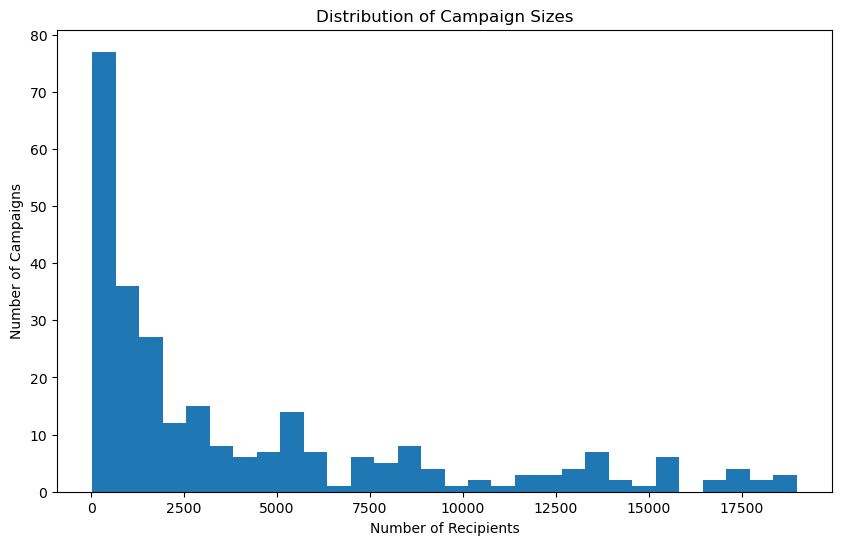

In [54]:

plt.figure(figsize=(10,6))

plt.hist(
    users_per_campaign,
    bins=30
)

plt.title('Distribution of Campaign Sizes')
plt.xlabel('Number of Recipients')
plt.ylabel('Number of Campaigns')

plt.show()

#### Top subject lines by open rate

In [55]:
# top subjectline by open rate
result.sort_values('open_mean', ascending = False)[
    ['open_mean', 'click_mean', 'count_valid', 'count_total']
].head(10)

,,open_mean,click_mean,count_valid,count_total
subject_line,preheader,,,,
Audi elektrisch rijden? Dan is 2025 beslissend,"Profiteer nog van 17% bijtelling, vóór de stijging in januari.",0.833285,0.001065,6850,6857
Rijd de nieuwe Mazda6e dit jaar nog met 17% bijtelling,Elektrisch rijden met de klasse van Japans vakmanschap.,0.805671,0.000000,1446,1447
Ontdek de Mazda die bij jou past,Tijdelijk tot €4.000 inruilvoordeel op diverse modellen.,0.787234,0.015927,1081,1082
Luxe tas van Fred de la Bretoniere? Wees er snel bij!,Tijdelijke actie met 51% voordeel bij Libelle.,0.779874,0.006135,1113,1168
Stap dit jaar in een Audi en verzeker uzelf van 17% bijtelling,Profiteer 60 maanden lang van lagere bijtelling.,0.779407,0.000000,9343,9463
Past de Mazda6e bij jouw zakelijke stijl?,Boek een proefrit en ontdek het comfort van elektrisch rijden.,0.778993,0.004263,1828,1840
Veelzijdig en stijlvol: maak kennis met de Mazda6e,Ontdek het zelf achter het stuur tijdens een proefrit.,0.768416,0.000938,2267,2281
"Jouw zomer, jouw krant – nu 4 weken voor 4 euro","Lees het AD, de Volkskrant, Trouw en meer.",0.761608,0.001886,8184,8231
De nieuwe standaard voor zakelijk rijden: Mazda6e,"Efficiënt elektrisch rijden met stijl, comfort en een aantrekkelijk leasetarief.",0.758786,0.002214,3329,3352


#### Top subject lines by click rate

In [56]:
# top subjectline by click rate
result.sort_values('click_mean', ascending = False)[
    ['click_mean', 'open_mean', 'count_valid', 'count_total']
].head(10)

,,click_mean,open_mean,count_valid,count_total
subject_line,preheader,,,,
Vul enquêtes in wanneer jou dat uitkomt,En ontvang jouw favoriete cadeaubonnen!,0.136000,0.746479,213,290
Meer weten over de impact van Hulphond Nederland?,"Lees hun verhaal én maak kans op een cadeaubon van €25,-.",0.040929,0.700815,859,1005
Ontdek hoe Hulphond Nederland levens verandert,"Meld je aan voor hun nieuwsbrief en maak kans op een Bol cadeaubon van €25,-.",0.040929,0.700815,859,1005
Ontdek het goede doel dat bij jouw past,"Lees de verhalen en maak kans op een Bol cadeaubon t.w.v. €25,-.",0.040929,0.700815,859,1005
Ontdek de Mazda die bij jou past,Tijdelijk tot €4.000 inruilvoordeel op diverse modellen.,0.015927,0.787234,1081,1082
12x Wetenschap in Beeld + telescoop,Beleef fascinerende verhalen en kijk verder dan ooit tevoren.,0.013603,0.530153,2222,2731
Best of Mazda: tijdelijk extra veel inruilvoordeel,Profiteer tot 30 november tot wel € 4.000 inruilvoordeel.,0.008900,0.716370,1234,1367
Tijdelijk tot €4.000 inruilvoordeel bij Mazda,Ontdek de veelzijdige Mazda line-up en profiteer tot 30 november.,0.008871,0.715441,2474,2742
80% al verkocht! laatste kans om in te stappen,De obligatieronde van Roadway Nederland sluit binnenkort.,0.007692,0.291667,144,167


### Subject line vs Engagement segmentation

In [57]:
print(result['open_mean'].describe())
print(result['click_mean'].describe())

count    189.000000
mean       0.520890
std        0.181064
min        0.000000
25%        0.460076
50%        0.554857
75%        0.638344
max        0.833285
Name: open_mean, dtype: float64
count    189.000000
mean       0.002467
std        0.011163
min        0.000000
25%        0.000000
50%        0.000498
75%        0.001227
max        0.136000
Name: click_mean, dtype: float64


In [58]:
# threshold for engagement rates
open_threshold = result['open_mean'].mean()
click_threshold = result['click_mean'].mean()

In [59]:
# classify subject lines into groups

result['open_group'] = result['open_mean'].apply(
    lambda x: 'high' if x > open_threshold else 'low')

result['click_group'] = result['click_mean'].apply(
    lambda x: 'high' if x > click_threshold else 'low')

In [60]:
# size check
result.groupby(['open_group', 'click_group']).size()

open_group  click_group
high        high           21
            low            91
low         high            5
            low            72
dtype: int64

In [61]:
# extract groups
high_open_high_click = result[
    (result['open_group'] == 'high') &
    (result['click_group'] == 'high')]

high_open_low_click = result[
    (result['open_group'] == 'high') &
    (result['click_group'] == 'low')]

low_open_high_click = result[
    (result['open_group'] == 'low') &
    (result['click_group'] == 'high')]

low_open_low_click = result[
    (result['open_group'] == 'low') &
    (result['click_group'] == 'low')]


#### High open + High click group

In [62]:
high_open_high_click[['open_mean', 'click_mean', 'count_valid', 'count_total']].sort_values('click_mean', ascending = False).head(10)

,,open_mean,click_mean,count_valid,count_total
subject_line,preheader,,,,
Vul enquêtes in wanneer jou dat uitkomt,En ontvang jouw favoriete cadeaubonnen!,0.746479,0.136000,213,290
Ontdek het goede doel dat bij jouw past,"Lees de verhalen en maak kans op een Bol cadeaubon t.w.v. €25,-.",0.700815,0.040929,859,1005
Ontdek hoe Hulphond Nederland levens verandert,"Meld je aan voor hun nieuwsbrief en maak kans op een Bol cadeaubon van €25,-.",0.700815,0.040929,859,1005
Meer weten over de impact van Hulphond Nederland?,"Lees hun verhaal én maak kans op een cadeaubon van €25,-.",0.700815,0.040929,859,1005
Ontdek de Mazda die bij jou past,Tijdelijk tot €4.000 inruilvoordeel op diverse modellen.,0.787234,0.015927,1081,1082
12x Wetenschap in Beeld + telescoop,Beleef fascinerende verhalen en kijk verder dan ooit tevoren.,0.530153,0.013603,2222,2731
Best of Mazda: tijdelijk extra veel inruilvoordeel,Profiteer tot 30 november tot wel € 4.000 inruilvoordeel.,0.716370,0.008900,1234,1367
Tijdelijk tot €4.000 inruilvoordeel bij Mazda,Ontdek de veelzijdige Mazda line-up en profiteer tot 30 november.,0.715441,0.008871,2474,2742
Luxe tas van Fred de la Bretoniere? Wees er snel bij!,Tijdelijke actie met 51% voordeel bij Libelle.,0.779874,0.006135,1113,1168


##### Insights
High open, high click group
- Subject lines and preheaders use broadly appealing and simple languages (discover, get to know)
- Explicit incentives (gift cards, financial benefits)
- Subject lines attracts attention
- Preheader communicate reward/next step
- Low effort, clear reward for audience
- Some high performing subject lines (top 10) are associated with smaller campaign sizes (may indicate more targeted audience)
- External factors beyond subject lines and preheaders may play a significant role

In [63]:
high_open_low_click[['open_mean', 'click_mean', 'count_valid', 'count_total']].sort_values('open_mean', ascending = False).head(10)

,,open_mean,click_mean,count_valid,count_total
subject_line,preheader,,,,
Audi elektrisch rijden? Dan is 2025 beslissend,"Profiteer nog van 17% bijtelling, vóór de stijging in januari.",0.833285,0.001065,6850,6857
Rijd de nieuwe Mazda6e dit jaar nog met 17% bijtelling,Elektrisch rijden met de klasse van Japans vakmanschap.,0.805671,0.000000,1446,1447
Stap dit jaar in een Audi en verzeker uzelf van 17% bijtelling,Profiteer 60 maanden lang van lagere bijtelling.,0.779407,0.000000,9343,9463
Veelzijdig en stijlvol: maak kennis met de Mazda6e,Ontdek het zelf achter het stuur tijdens een proefrit.,0.768416,0.000938,2267,2281
"Jouw zomer, jouw krant – nu 4 weken voor 4 euro","Lees het AD, de Volkskrant, Trouw en meer.",0.761608,0.001886,8184,8231
De nieuwe standaard voor zakelijk rijden: Mazda6e,"Efficiënt elektrisch rijden met stijl, comfort en een aantrekkelijk leasetarief.",0.758786,0.002214,3329,3352
Probeer nu MAX Magazine vrijblijvend,Vraag nu jou 4 proefnummers aan.,0.753238,0.000239,8494,8613
De volledig nieuwe Mazda CX-6e in het echt bewonderen?,Kom langs tijdens de preview en ervaar het design en comfort zelf.,0.751258,0.000578,3578,3581
Nespresso zonder kosten uitproberen?,Altijd moeiteloos kwaliteitskoffie op de werkvloer.,0.744581,0.000000,1061,1088


#### High open + Low click group

##### Insights
High open, low click group
- Subject lines and preheaders use strong hooks (financial benefits, high value products) (tax advantage, discounts, cars)
- Offers require higher commitment (large purchases, test drives) that not immediately relevant to all

In [64]:
low_open_high_click[['open_mean', 'click_mean', 'count_valid', 'count_total']].sort_values('click_mean', ascending = False).head(10)

,,open_mean,click_mean,count_valid,count_total
subject_line,preheader,,,,
80% al verkocht! laatste kans om in te stappen,De obligatieronde van Roadway Nederland sluit binnenkort.,0.291667,0.007692,144,167
Internationaal groeien in een onzekere wereld?,Plan een gratis adviesgesprek en ontdek de kansen & risico’s.,0.319277,0.006579,166,177
Pensioen regelen voor je werknemers: 10 dingen die je moet weten,Je kostbare personeel behouden en nieuw talent aantrekken in deze krappe arbeidsmarkt?,0.452951,0.003241,627,705
Neem meer dan 25 tijdschriften makkelijk mee op reis!,Probeer Mijn Magazines nu voor maar 1 euro per week.,0.472034,0.002616,1180,1282
Een wereld zonder lepra in 2040?,Ontdek hoe jij daaraan kunt bijdragen via onze nieuwsbrief.,0.012391,0.002567,12832,13933


#### Low open + High click group

##### Insights 
Low open, high click group
- Subject lines focus on specific, niche topics (security, finance)
- May not attract broad attention (low open rate)
- Generate stronger engagement among a small, relevant group of audience (high click rate)

In [65]:
low_open_low_click[['open_mean', 'click_mean', 'count_valid', 'count_total']].sort_values('open_mean', ascending = True).head(10)

,,open_mean,click_mean,count_valid,count_total
subject_line,preheader,,,,
Laatste kans: 4 weken jouw krant voor 1 euro per week,"Lees o.a. Het AD, de Volkskrant en Trouw. Mis het niet!",0.000000,0.0,1229,1417
Wat zit er in Donalds strandtas?,Ontdek het pakket en lees de leukste avonturen deze zomer.,0.000000,0.0,18304,20372
Deze goede doelen verdienen jouw aandacht,"Schrijf je in voor de nieuwsbrief en maak kans op €25,- bij Bol.com.",0.000000,0.0,431,453
Heb je deze deals al gezien?,Direct-Doen is terug met nieuwe aanbiedingen en extra’s.,0.000000,0.0,1907,2205
Hoe reist jouw zorgpersoneel straks naar het werk?,Ontdek hoe NS Zakelijk mobiliteit in de zorg toekomstbestendig maakt.,0.033094,0.0,6678,7562
Succesvol zakendoen in het buitenland?,Plan een gratis adviesgesprek en ontdek wat RVO voor jou kan betekenen.,0.051643,0.0,213,282
Wil jij ook je bedrijf internationaal laten groeien?,"RVO helpt; met kennis, contacten & financieringen.",0.051643,0.0,213,282
"{$voornaam|default=Beste}, Mis het niet: het Empoyer Brandonderzoek 2025",Zo wordt je aantrekkelijke werkgevers binnen {{ contact.branche }}.,0.078512,0.0,242,311
Frequent verzuim op de werkvloer?,Meld je aan voor het webinar of start direct met praktische tools.,0.117647,0.0,51,65


### Low open + Low click group

##### Insights
Low open, low click group
- Subjectlines and preheaders tend to be vague
- Not communicate a specific benefit, urgency or incentive
- Campaign size does not explain poor performance here

## User Engagement Analysis

Explore how user characteristics (gender, age, and interests) relate to engagement metrics

### Overview

#### Data preparation

In [66]:
# open and click rates per user
df_user = df_final.groupby('user_id').agg(
    open_rate = ('open', 'mean'),
    click_rate = ('click', 'mean'),
    total_emails = ('open', 'count')
).reset_index()

# add user info back
df_user = df_user.merge(
    df_final[['user_id', 'gender', 'age', 'interests']].drop_duplicates(subset = 'user_id'),
    on = 'user_id',
    how = 'left'
)

In [67]:
print(df_user['open_rate'].describe())
print(df_user['click_rate'].describe())

count    17963.000000
mean         0.536929
std          0.283799
min          0.000000
25%          0.285714
50%          0.576923
75%          0.789474
max          0.987342
Name: open_rate, dtype: float64
count    19213.000000
mean         0.001209
std          0.016720
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.818182
Name: click_rate, dtype: float64


In [68]:
df_user.isna().sum()

user_id             0
open_rate        2037
click_rate        787
total_emails        0
gender              0
age             15153
interests           0
dtype: int64

In [69]:
print(df_final.groupby('user_id')['open'].apply(
    lambda x: set(x.dropna().unique())
).value_counts())

print(df_final.groupby('user_id')['click'].apply(
    lambda x: set(x.dropna().unique())
).value_counts())

open
{0.0, 1.0}    17793
{}             2037
{0.0}           170
Name: count, dtype: int64
click
{0.0}         19019
{}              787
{0.0, 1.0}      194
Name: count, dtype: int64


##### Insights
- 2037 users (10.19%) have unusable open data
- 787 users (3.94%) have unusable click data

In [70]:
# drop users with unsuable engagement data
df_user_clean = df_user.dropna(subset = ['open_rate', 'click_rate'])
df_user_clean.shape

(17286, 7)

In [71]:
print(df_user[df_user['open_rate'].isna() & df_user['click_rate'].notna()].shape)
print(df_user[df_user['click_rate'].isna() & df_user['open_rate'].notna()].shape)

(1927, 7)
(677, 7)


In [72]:
print(df_user_clean['open_rate'].describe())
print(df_user_clean['click_rate'].describe())

count    17286.000000
mean         0.542700
std          0.281576
min          0.000000
25%          0.294118
50%          0.585961
75%          0.791667
max          0.987342
Name: open_rate, dtype: float64
count    17286.000000
mean         0.001187
std          0.015772
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.818182
Name: click_rate, dtype: float64


array([[<Axes: title={'center': 'open_rate'}>,
        <Axes: title={'center': 'click_rate'}>]], dtype=object)

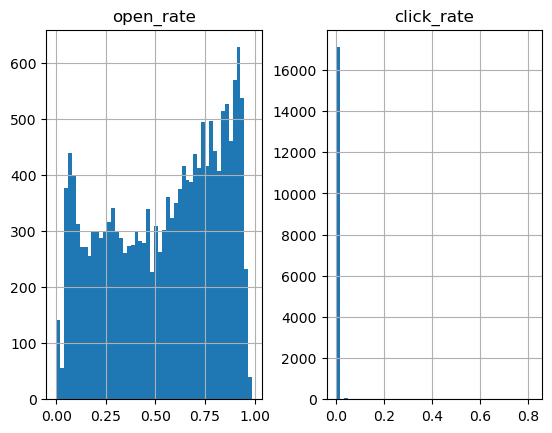

In [73]:
df_user_clean[['open_rate', 'click_rate']].hist(bins=50)

In [74]:
# click rate quantile check
df_user_clean['click_rate'].quantile([
    0.5, 0.75, 0.9, 0.95, 0.99, 0.999])

0.500    0.000000
0.750    0.000000
0.900    0.000000
0.950    0.000000
0.990    0.036145
0.999    0.281250
Name: click_rate, dtype: float64

##### Insights
- 95% of users NEVER click
- Top 1% is small clickers (3.61% click rate)
- Top 0.1% is heavy clickers (28.13% click rate)

In [75]:
# click rate quantile check for users who DO click
df_user_clean[df_user_clean['click_rate'] > 0]['click_rate'].quantile([
    0.5, 0.75, 0.9, 0.95, 0.99])

0.50    0.065217
0.75    0.156076
0.90    0.280903
0.95    0.321452
0.99    0.369069
Name: click_rate, dtype: float64

##### Insights
- Higher click rates mmong people who DO click
- Clickers are quite engaged once they exist
- Click is a rare but strong signal

In [76]:
print('% of users who ever click:', (df_user_clean['click_rate'] > 0).mean())

% of users who ever click: 0.010528751590882795


#### Classify users into engagment segmentation

In [77]:
# threshold for high and low open
open_threshold = df_user_clean['open_rate'].median()        #median because open rate is reasonably spread, but not symmetric

In [78]:
df_user_clean = df_user.dropna(subset=['open_rate', 'click_rate']).copy()

In [79]:
# create user segment

# open segment
df_user_clean['open_segment'] = np.where(
    df_user_clean['open_rate'] >= open_threshold,
    'high_open',
    'low_open')

# click segment
def classify_click(x):
    if x == 0:
        return 'no_click'
    else:
        return 'click'
    
df_user_clean['click_segment'] = df_user_clean['click_rate'].apply(classify_click)

In [80]:
# segment size
df_user_clean.groupby(['open_segment', 'click_segment']).size()

open_segment  click_segment
high_open     click              42
              no_click         8601
low_open      click             140
              no_click         8503
dtype: int64

##### Insights
- Most users frequently open emails
- Only a very small porportion proceed to click
- Users with lower open rates have higher click rates -> selective engagement may indicate stronger intent

### Gender Analysis

In [81]:
df_user_clean.groupby(
    ['open_segment', 'click_segment'])['gender'].value_counts(normalize = True)

open_segment  click_segment  gender
high_open     click          male      0.761905
                             female    0.214286
                             other     0.023810
              no_click       female    0.560865
                             male      0.417393
                             other     0.021742
low_open      click          male      0.514286
                             female    0.485714
              no_click       female    0.559214
                             male      0.420440
                             other     0.020346
Name: proportion, dtype: float64

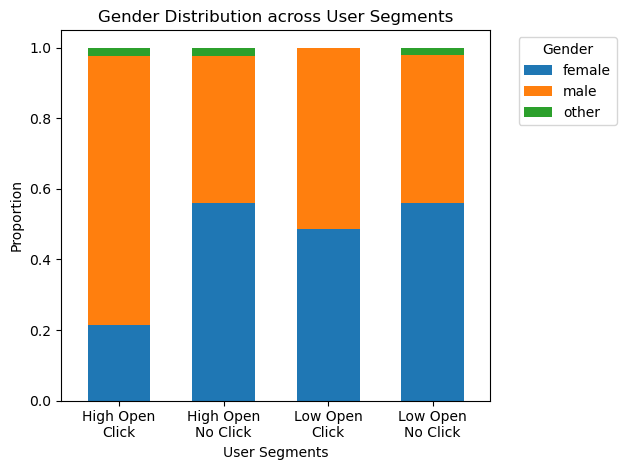

In [82]:
# bar chart

# data prep
gender_distribution = df_user_clean.groupby(
    ['open_segment','click_segment','gender']).size().unstack(fill_value = 0)

# convert to proportions
gender_distribution = gender_distribution.div(gender_distribution.sum(axis = 1), axis = 0)

# plot
gender_distribution.plot(kind = 'bar', stacked = True, width = 0.6)

# rename x labels
plt.xticks(
    ticks=range(len(gender_distribution.index)),
    labels=[
        'High Open\nClick',
        'High Open\nNo Click',
        'Low Open\nClick',
        'Low Open\nNo Click'],
    rotation=0)

plt.title('Gender Distribution across User Segments')
plt.ylabel('Proportion')
plt.xlabel('User Segments')
plt.legend(title='Gender', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

##### Insights
- Male users are more likely to click (strongest in high open high click, with 76% male)
- Female users are more common in non clicking segment
- Conclusion: male users are more likely to convert from opening to clicking

In [83]:
df_user_clean.groupby('gender')[['open_rate', 'click_rate']].mean()

,open_rate,click_rate
gender,,
female,0.542557,0.001080
male,0.541856,0.001382
other,0.563526,0.000148


In [84]:
df_user_clean['gender'].value_counts(normalize = True)

gender
female    0.558602
male      0.420514
other     0.020884
Name: proportion, dtype: float64

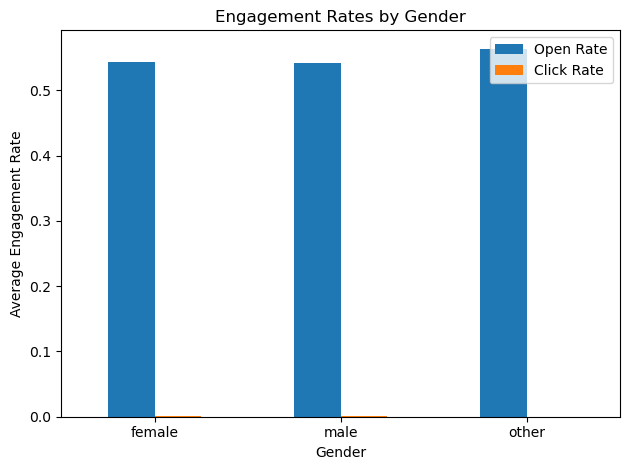

In [85]:
# bar chart

# data prep
gender_rates = df_user_clean.groupby('gender', observed = True)[['open_rate', 'click_rate']].mean()

#plot
gender_rates.plot(kind='bar')

plt.title('Engagement Rates by Gender')
plt.ylabel('Average Engagement Rate')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.legend(['Open Rate', 'Click Rate'])
plt.tight_layout()
plt.show()

### Age Analysis

In [86]:
df_user_clean.columns

Index(['user_id', 'open_rate', 'click_rate', 'total_emails', 'gender', 'age',
       'interests', 'open_segment', 'click_segment'],
      dtype='object')

In [87]:
df_user_clean['age'].describe()

count    4135.000000
mean       51.461669
std        14.674864
min         8.000000
25%        39.000000
50%        50.000000
75%        63.000000
max       112.000000
Name: age, dtype: float64

In [88]:
# remove unrealistic age
df_user_clean['age_clean'] = df_user_clean['age'].where(
    (df_user_clean['age'] >= 18) &
    (df_user_clean['age'] <= 90))

##### Remark
Unrealistic age values (outside the range 18-90) were removed to ensure data quality

In [89]:
# create age group
df_user_clean['age_group'] = pd.cut(
    df_user_clean['age_clean'],
    bins = [18, 35, 50, 65, 90],
    labels = ['18-35', '35-50', '50-65', '65+'])

# count users per age group
df_user_clean['age_group'].value_counts(normalize = True)

age_group
35-50    0.343113
50-65    0.289282
65+      0.207808
18-35    0.159796
Name: proportion, dtype: float64

#### Engagement rate for age groups

In [90]:
# engagement rate for age groups
df_user_clean.groupby('age_group', observed = True)[['open_rate', 'click_rate']].mean()

,open_rate,click_rate
age_group,,
18-35,0.617269,0.000000
35-50,0.568097,0.000106
50-65,0.466244,0.001637
65+,0.429264,0.003288


In [91]:
df_user_clean[['age_group']].value_counts(normalize = True)

age_group
35-50        0.343113
50-65        0.289282
65+          0.207808
18-35        0.159796
Name: proportion, dtype: float64

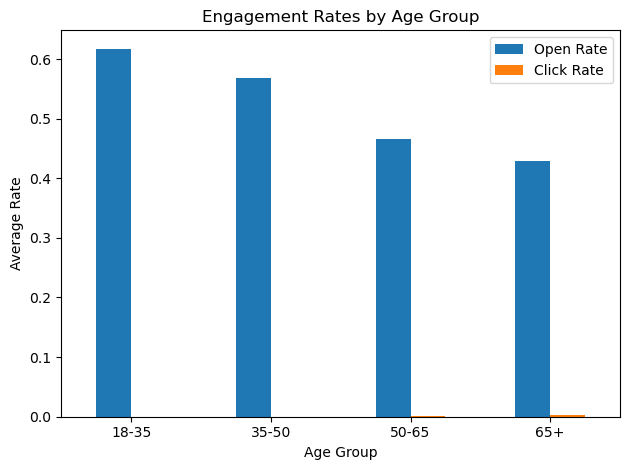

In [92]:
# bar chart

# data prep
age_rates = df_user_clean.groupby('age_group', observed=True)[['open_rate', 'click_rate']].mean()

#plot
age_rates.plot(kind='bar')

plt.title('Engagement Rates by Age Group')
plt.ylabel('Average Rate')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.legend(['Open Rate', 'Click Rate'])
plt.tight_layout()
plt.show()

##### Insights
- Younger users (18-35) have the highest open rate, but rarely click
- Older users (50+) have lower open rate, but more likely to click after opening
- Open rate decrease with age
- Click rate increases with age

#### Age groups vs Engagement segmentation

In [93]:
# age segment size
age_segment = pd.crosstab(
    df_user_clean['age_group'],
    [df_user_clean['open_segment'], df_user_clean['click_segment']],
    normalize = 'index')

age_segment

open_segment  high_open            low_open          
click_segment     click  no_click     click  no_click
age_group                                            
18-35          0.000000  0.626707  0.000000  0.373293
35-50          0.000707  0.520141  0.002120  0.477032
50-65          0.001676  0.381391  0.012573  0.604359
65+            0.008168  0.324387  0.028005  0.639440

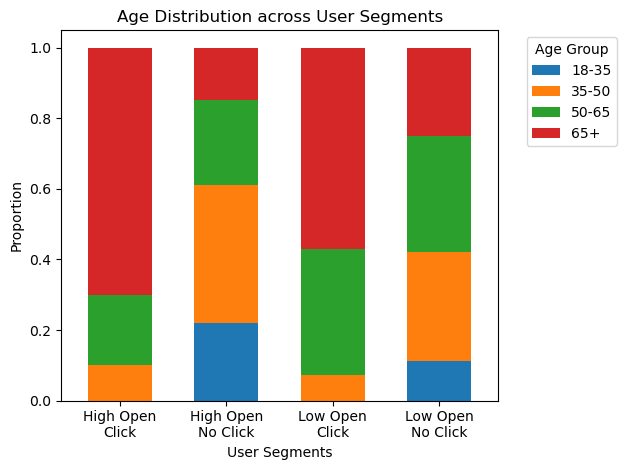

In [94]:
df_user_clean['combined_segment'] = (
    df_user_clean['open_segment'] + ' & ' + df_user_clean['click_segment'])

age_by_segment = pd.crosstab(
    df_user_clean['combined_segment'],
    df_user_clean['age_group'],
    normalize = 'index')

# plot
age_by_segment.plot(kind = 'bar', stacked = True, width = 0.6)

# rename x labels
plt.xticks(
    ticks=range(len(age_by_segment.index)),
    labels=[
        'High Open\nClick',
        'High Open\nNo Click',
        'Low Open\nClick',
        'Low Open\nNo Click'],
    rotation=0)

plt.title('Age Distribution across User Segments')
plt.ylabel('Proportion')
plt.xlabel('User Segments')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

##### Insights
- Older users (50+) are more likely to click than younger users
- Younger users (18-35) almost never click (regardless of open level)

### Interest Analysis

#### Explore top interests among users

In [95]:
# explode data with interests
df_interests = df_user_clean.copy()
df_interests = df_interests.explode('interests')

In [96]:
# top user interests
top_interests = df_interests['interests'].value_counts().head(10)
print(top_interests)

interests
bladen         17115
acties         16890
kranten        16738
winactie       16167
cadeau         16060
kortingen      16056
energie        15522
goededoelen    14345
onderzoek      14124
auto           11837
Name: count, dtype: int64


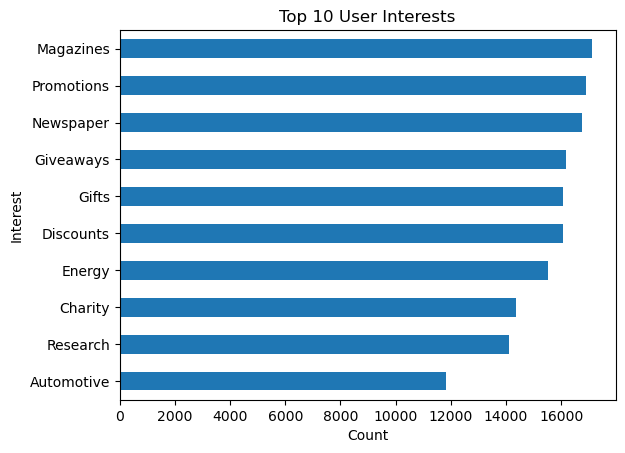

In [97]:
# bar chart

# english translation
interest_map = {
    'bladen': 'Magazines',
    'acties': 'Promotions',
    'kranten': 'Newspaper',
    'winactie': 'Giveaways',
    'cadeau': 'Gifts',
    'kortingen': 'Discounts',
    'energie': 'Energy',
    'goededoelen': 'Charity',
    'onderzoek': 'Research',
    'auto': 'Automotive'}

top_interests_en = top_interests.rename(index = interest_map)

#plot
top_interests_en.plot(kind='barh')
plt.title('Top 10 User Interests')
plt.xlabel('Count')
plt.ylabel('Interest')
plt.gca().invert_yaxis()
plt.show()

##### Insights
- Promotional interests dominate user preferences (promotions, giveaways, gifts, discounts)
- Users show strong interests in informational content (magazines, newspaper, research)
- Commercial topics are also significant (energy and automotive)

#### Explore interests with high engagment rates

In [98]:
# aggregate engagement per interest
interest_engagement = df_interests.groupby('interests').agg(
    open_mean=('open_rate', 'mean'),
    click_mean=('click_rate', 'mean'),
    count=('user_id', 'count'))

interest_engagement.head()

,open_mean,click_mean,count
interests,,,
acties,0.551747,0.001207,16890
android,0.289489,0.001972,1328
audi,0.631697,0.000649,9299
auto,0.574323,0.000851,11837
auto inruilen,0.614763,0.000875,9740


In [99]:
interest_counts = df_interests['interests'].value_counts()
interest_counts.describe()

count       60.000000
mean      6146.933333
std       5542.869329
min          1.000000
25%        723.500000
50%       5429.500000
75%      10089.000000
max      17115.000000
Name: count, dtype: float64

In [100]:
# remove small counts

#threshold for counts
count_threshold = threshold = df_interests['interests'].value_counts().quantile(0.25)
interest_filtered = interest_engagement[
    interest_engagement['count'] >= count_threshold]

##### Remark
Interests with low counts (bottom 25%) to avoid unreliable estimates

In [101]:
# sort interests by open rates
interest_filtered.sort_values('open_mean', ascending=False).head(10)

,open_mean,click_mean,count
interests,,,
bezorgmaaltijden,0.753736,0.000156,1806
mazda6e,0.674259,0.001288,4399
finance,0.661999,0.000579,7736
verzekering,0.660851,0.000921,6583
beleggen,0.659138,0.000777,7154
bank,0.648134,0.000579,7270
mercedes,0.648010,0.001059,2704
hypotheek,0.642729,0.000072,1516
bedrijfswagen,0.637129,0.000845,1459


In [102]:
# sort interests by click rates
interest_filtered.sort_values('click_mean', ascending=False).head(10)

,open_mean,click_mean,count
interests,,,
windows,0.342804,0.002584,2009
android,0.289489,0.001972,1328
mazda6e,0.674259,0.001288,4399
goededoelen,0.566153,0.001282,14345
acties,0.551747,0.001207,16890
bladen,0.547079,0.001195,17115
ondernemers,0.626589,0.001139,5659
mercedes,0.648010,0.001059,2704
bedrijven,0.571938,0.001017,2413


Some overlap between popular and interests with high engagement, but the relationship is not strong or consistent

## Campaign Topic Analysis

### Data preparation

In [103]:
# create campaign topic table
df_campaigns = df2.copy()
campaign_topics = df_campaigns[['mailing_id', 'mailing_info', 'subject_line', 'preheader']].copy()

# drop duplicates
campaign_topics = campaign_topics.drop_duplicates(subset = ['mailing_id'])

In [104]:
campaign_topics.head()

,mailing_id,mailing_info,subject_line,preheader
0,1422,2026/04/22 CENTRAAL BEHEER_RNC_2,Hoe lang kun jij zonder inkomen als je arbeids...,NaN
1,1420,2026/04/21 CENTRAAL BEHEER_RNC_1,Hoe lang kun jij zonder inkomen als je arbeids...,NaN
2,1419,2026/04/21 Direct Doen wk17 - Donald Duck Stra...,Wat zit er in Donalds strandtas?,Ontdek het pakket en lees de leukste avonturen...
3,1418,2026/04/21 CRS wk17 - Donald Duck Strandpakket,Wat zit er in Donalds strandtas?,Ontdek het pakket en lees de leukste avonturen...
4,1417,2026/04/21 CPX wk17 - Donald Duck Strandpakket,Wat zit er in Donalds strandtas?,Ontdek het pakket en lees de leukste avonturen...


In [105]:
campaign_topics.shape

(337, 4)

In [106]:
# add classification column
campaign_topics['main_topic'] = ''

In [107]:
# combine mailing info, subject line, preheader
campaign_topics['combined_info'] = (
    campaign_topics['mailing_info'].fillna('') + '' + 
    campaign_topics['subject_line'].fillna('') + '' + 
    campaign_topics['preheader'].fillna(''))

In [108]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'Mazda|Audi|Hyundai|Toyota|mobiliteit', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
21,1367,2026/03/26 - HYUNDAIComfortabel rijden met een...
22,1365,2026/04/02 - Mazda CX 6e - RODe volledig nieuw...
26,1361,2026/03/24 - Mazda CX 6e - RNOEen nieuwe stand...
28,1355,260319 - NS - Duurzame mobiliteit in de zorg R...
29,1354,2026/03/19 - Mazda CX 6e - UITROLOntdek de rui...
...,...,...
304,735,250515 Mazda6e zakelijke - UITROLDe Mazda6e: e...
308,729,250508 Mazda6e zakelijke - S2Maak nu kennis me...
312,721,250508 Mazda6e zakelijke - S1De Mazda6e: elekt...
334,646,2025/03/25 MAZDA CX-60 JAPAN ROJouw proefrit i...


In [109]:
# classify automotive/mobility topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'Mazda|Audi|Hyundai|Toyota|mobiliteit', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Automotive & Mobility'

In [110]:
campaign_topics[['mailing_id', 'main_topic']].head(24)

,mailing_id,main_topic
0,1422,
1,1420,
2,1419,
3,1418,
4,1417,
5,1411,
6,1408,
7,1403,
8,1402,
9,1400,


In [111]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'magazine|krant|film|media|De Telegraaf|Libelle|Donald|economie|VARAgids|politiek|landleven|wetenschap', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
2,1419,2026/04/21 Direct Doen wk17 - Donald Duck Stra...
3,1418,2026/04/21 CRS wk17 - Donald Duck Strandpakket...
4,1417,2026/04/21 CPX wk17 - Donald Duck Strandpakket...
10,1399,2026/04/14 CRS WK16 – MAX + HEMAMAX Magazine é...
11,1398,2026/04/14 CPX WK16 – MAX + HEMAMAX Magazine é...
...,...,...
309,728,2025/05/13 CPX - LANDLEVENLaatste kans: 6x Lan...
322,692,2025/05/29 DPG 4W1E4 weken jouw favoriete kran...
327,669,2025/04/24 - MM Vipmedia - Voorjaarsactie TWOL...
328,668,2025/04/24 CPX - MM MAX Magazine - 4 gratis nr...


In [112]:
# classify media/publishing topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'magazine|krant|film|media|De Telegraaf|Libelle|Donald|economie|VARAgids|politiek|landleven|wetenschap', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Media & Publishing'

In [113]:
campaign_topics[['mailing_id', 'main_topic']].head(24)

,mailing_id,main_topic
0,1422,
1,1420,
2,1419,Media & Publishing
3,1418,Media & Publishing
4,1417,Media & Publishing
5,1411,
6,1408,
7,1403,
8,1402,
9,1400,


In [114]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'inkomen|pensioen|Roadway|capital|invest|beleggen|AOV|Tikkie|autoverzekering', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
0,1422,2026/04/22 CENTRAAL BEHEER_RNC_2Hoe lang kun j...
1,1420,2026/04/21 CENTRAAL BEHEER_RNC_1Hoe lang kun j...
5,1411,2026/04/20 CENTRAAL BEHEER_Uitrol 2Weet jij ho...
6,1408,2026/04/16 CENTRAAL BEHEER_Uitrol 1Weet jij ho...
7,1403,2026/04/14 CENTRAAL BEHEER S2Nu 50% korting op...
8,1402,2026/04/14 CENTRAAL BEHEER S1Weet jij hoelang ...
255,838,250701 Roadway - RNO80% al verkocht! laatste k...
256,831,2025/06/26 ASR_Pensioen_HM DEFPensioen regelen...
257,828,2025/06/26 ASR_Pensioen_HMPensioen regelen voo...
263,819,250624 Roadway - RNCInvesteer nu met 12% vast ...


In [115]:
# classify finance/investment topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'inkomen|pensioen|Roadway|capital|invest|beleggen|AOV|Tikkie|autoverzekering', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Finance & Investment'

In [116]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'Engie|zonne|powerbank|airco', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
183,995,2025/10/08 - CPX - ENGIEMaak de zin compleet e...
195,959,2025/09/23 - CPX - ENGIEMaak de zin compleet e...
209,935,2025/09/11 CPX - MM - ENGIEHeb jij het het ENG...
216,926,2025/09/02 TEST Joyce ENGIE DEF.{$voornaam|def...
217,925,2025/09/02 TEST Joyce ENGIE (Copy 20250908-13:...
218,924,"2025/09/02 TEST Joyce ENGIE{$voornaam}, downlo..."
223,914,2025/09/02 CPX - MM - ENGIEXX
239,883,2025/08/12 CPX - MM - ENGIE POWERBANKXX
254,846,2025/07/02 - CPX - MM ENGIE SimpSune Solar Pow...
289,761,2025/05/27 CPX - MM - ENGIESpeel mee met de EN...


In [117]:
# classify energy/sustainability topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'Engie|zonne|powerbank|airco', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Energy & Sustainability'

In [118]:
campaign_topics['main_topic'].value_counts(dropna = False)

main_topic
                           148
Automotive & Mobility       78
Media & Publishing          77
Finance & Investment        22
Energy & Sustainability     12
Name: count, dtype: int64

In [119]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'goede doelen|hulp|Lepra|Oranje Fond|burendag', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
96,1198,Dec CRS stichting LepraEen wereld zonder lepra...
97,1197,Dec CRS Hulphond 2Ontdek hoe Hulphond Nederlan...
98,1196,Dec CRS Hulphond 1Meer weten over de impact va...
99,1195,Dec CRS Goede doelen 2Ontdek het goede doel da...
100,1194,Dec CRS Goede doelen 1Ontmoet 5 goede doelen d...
108,1146,251126 CPX stichting Lepra - WK48Een wereld zo...
111,1135,20 Nov CRS Goede doelen 2Ontdek het goede doel...
112,1134,20 Nov CRS Goede doelen 1Ontmoet 5 goede doele...
113,1133,20 Nov CRS Hulphond 2Ontdek hoe Hulphond Neder...
114,1132,20 Nov CRS Hulphond 1Meer weten over de impact...


In [120]:
# classify charity/social impact topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'goede doelen|hulp|Lepra|Oranje Fond|burendag', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Charity & Social Impact'

In [121]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'MKbasics|RANDSTAD|Regus|zaken|ziekteverzuim|groeien', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
65,1266,"2026/01/27 - RANDSTAD RNO deel 2Mis het niet, ..."
72,1257,"2026/01/27 - RANDSTAD RNC deel 2Mis het niet, ..."
73,1252,2026/01/22 - RANDSTAD Uitrol 2 - Restandupdate...
74,1251,"2026/01/20 - RANDSTAD Uitrol 2B{$voornaam}, jo..."
75,1248,2026/01/20 - RANDSTAD Uitrol 2Aupdate HR wet- ...
76,1246,"2026/01/19 - RANDSTAD RNO_1Mis het niet, {$voo..."
81,1239,"2026/01/14 - RANDSTAD REMMis het niet, {$voorn..."
87,1228,2026/01/05 - RANDSTAD{$voornaam|default=Beste}...
198,952,2025/09/19 RANDSTAD - RNO{$voornaam|default=Be...
200,947,2025/09/16 RANDSTAD - RNC{$voornaam|default=Be...


In [122]:
# classify business topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'MKbasics|RANDSTAD|Regus|zaken|ziekteverzuim|groeien', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Business'

In [123]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'Nespresso|Uitgekookt', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
45,1312,26/02/19 Nespresso - Sell Fase - F7Nespresso z...
47,1303,26/02/12 Nespresso - Tell Fase - F5Een prettig...
54,1290,26/02/09 Nespresso - Tell Fase - F4Hoe creëer ...
60,1282,26/02/05 Nespresso - Touch Fase - F2 RNOIs kof...
69,1260,26/01/27 Nespresso - Sell FaseNespresso zonder...
70,1259,26/02/09 Nespresso - Tell Fase - F3Hoe creëer ...
71,1258,26/02/03 Nespresso - Touch FaseIs koffie het g...
147,1075,25/11/06 NESPRESSO HORECA RNOMaak van koffie e...
149,1065,25/11/04 NESPRESSO HORECA RNCBaristakwaliteit ...
161,1033,25/10/20 NESPRESSO HORECABarista-kwaliteit kof...


In [124]:
# classify food/beverages topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'Nespresso|Uitgekookt', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Food & Beverages'

In [125]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'Odido', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
148,1066,251104 - Odido - RNOFirefly laat zien hoe lich...
151,1055,251030- Odido - UitrolDeze slimme oplossing in...
171,1015,251028 - Odido - S1Deze slimme oplossing inspi...


In [126]:
# classify telecom/technology topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'Odido', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Telecom & Technology'

In [127]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'Belife|mentaal|Pearle', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
173,1012,2025/10/13 - BELIFE - RNOMentaal sterker in we...
185,988,2025/10/06 - BELIFE - RNCMentaal sterker worde...
190,966,2025/09/24 - BELIFEVergroot je mentale flexibi...
260,822,2025/06/24 PEARLE - Reminder non opens 40-60La...
261,821,2025/06/24 PEARLE - Reminder non opens 16-35La...
270,801,2025/06/03 PEARLE - Reminder non clicks 40-60L...
271,800,2025/06/03 PEARLE - Reminder non clicks 16-35L...
274,793,2025/06/03 PEARLE - Uitrol 40-60Probeer gratis...
275,792,2025/06/03 PEARLE - Uitrol 15-35Probeer gratis...
280,783,2025/06/03 PEARLE - S2Test nu gratis contactle...


In [128]:
# classify health/wellbeing topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'Belife|mentaal|Pearle', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Health & Wellbeing'

In [129]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'loterij|Stempunt|prijzenrad|lifepoints|e-bike|geluk', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
14,1389,2026/04/07 CPX WK15 – BESPARENMaak kans op een...
17,1379,2026/03/31 Stempunt Loterij - CRSWat levert jo...
18,1378,2026/03/31 Stempunt Loterij - direct doenWat l...
33,1345,2026/03/13 Online Acties - Gemakkelijk Bespare...
41,1328,2026/03/03 Stempunt Loterij - direct doenWat v...
50,1297,2026/02/09 CPX wk8 - Stempunt LoterijWat vind ...
94,1200,Dec CRS Stempunt 2Vul enquêtes in wanneer jou ...
95,1199,"Dec CRS Stempunt 1Laat je mening horen, ontvan..."
153,1048,2025/10/28 STAATSLOTERIJ - RNOMis jouw kans op...
158,1040,2025/10/21 STAATSLOTERIJ - RNCLaat €1.000.000 ...


In [130]:
# classify lottery/games topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'loterij|Stempunt|prijzenrad|lifepoints|e-bike|geluk', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Lottery & Games'

In [131]:
campaign_topics['main_topic'].value_counts(dropna = False)

main_topic
Automotive & Mobility      78
Media & Publishing         77
Business                   38
Charity & Social Impact    32
Finance & Investment       22
                           22
Lottery & Games            21
Food & Beverages           20
Health & Wellbeing         12
Energy & Sustainability    12
Telecom & Technology        3
Name: count, dtype: int64

In [132]:
campaign_topics[
    campaign_topics['combined_info'].str.contains(
        'bespaartips|deals|Welke deal past bij jou deze week?', 
        case = False, 
        na = False,
        regex = True)
][['mailing_id', 'combined_info']]

,mailing_id,combined_info
40,1329,2026/02/19 CPX VZMAIL wk10Welke deal past bij ...
42,1320,260223 Direct doen verzamelmailHeb je deze dea...
43,1314,2026/02/19 CPX VZMAILWelke deal past bij jou d...
55,1289,2026/02/05 - Direct Doen D (maandag)Direct-Doe...
57,1285,"2026/02/05 - Direct Doen DDirect-Doen, terug v..."
64,1267,"2026/01/29 - Direct Doen CDirect-Doen, terug v..."
80,1240,"2026/01/12 - Direct Doen CDirect-Doen, terug v..."
85,1234,2026/01/12 - Direct Doen AVoor het eerst hier?...
116,1129,20 Nov CRS Verzamelmail 1Maak kennis met de be...
126,1102,12 Nov CRS Verzamelmail 1Maak kennis met de be...


In [133]:
# classify retail/promotion topics
campaign_topics.loc[
    campaign_topics['combined_info'].str.contains(
        'bespaartips|deals|Welke deal past bij jou deze week?', 
        case = False, 
        na = False,
        regex = True),
        'main_topic'
] = 'Retail & Promotion'

In [134]:
# classify unknown topics
campaign_topics.loc[
    campaign_topics['main_topic'].str.strip() == '',
    'main_topic'
] = 'Unknown'

### Campaign topics distribution

In [135]:
# topics distribution
topic_counts = campaign_topics['main_topic'].value_counts(dropna = False)
print(topic_counts)

main_topic
Automotive & Mobility      78
Media & Publishing         77
Business                   38
Charity & Social Impact    32
Finance & Investment       22
Lottery & Games            21
Food & Beverages           20
Unknown                    12
Health & Wellbeing         12
Energy & Sustainability    12
Retail & Promotion         10
Telecom & Technology        3
Name: count, dtype: int64


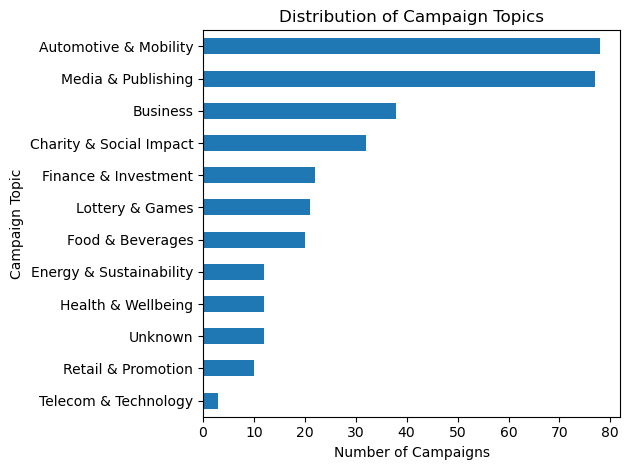

In [136]:
# plot

topic_counts = campaign_topics['main_topic'].value_counts().sort_values()

topic_counts.plot(kind='barh')
plt.title('Distribution of Campaign Topics')
plt.xlabel('Number of Campaigns')
plt.ylabel('Campaign Topic')
plt.tight_layout()
plt.show()

##### Insights
- Automotive & Mobility and Media & Publishing are dominant
- Business and Charity & Social Impact are moderately represented
- Telecom & Technology and Retail & Promotion are relatively rare, may provide limited analytical reliability due to low number of observations
- Campaign distribution is uneven across campaign topics

### Campaign topic - User distribution

In [137]:
campaign_topics.columns

Index(['mailing_id', 'mailing_info', 'subject_line', 'preheader', 'main_topic',
       'combined_info'],
      dtype='object')

In [138]:
df_final.columns

Index(['user_id', 'gender', 'birth_date', 'postcode', 'city', 'interests',
       'age', 'n_interests', 'open_type', 'click_type', 'mailing_id', 'open',
       'click', 'mailing_info', 'subject_line', 'preheader'],
      dtype='object')

In [139]:
# merge 2 datasets
df_final_topic = df_final.merge(
    campaign_topics[['mailing_id','main_topic']],
    on = 'mailing_id',
    how = 'left'
)

df_final_topic[['mailing_id', 'main_topic', 'open', 'click']].head()

,mailing_id,main_topic,open,click
0,668,Media & Publishing,0.0,0.0
1,692,Media & Publishing,0.0,0.0
2,714,Energy & Sustainability,0.0,0.0
3,733,Lottery & Games,0.0,0.0
4,761,Energy & Sustainability,0.0,0.0


In [140]:
df_final_topic['main_topic'].isna().sum()

28850

In [141]:
df_final_topic[df_final_topic['main_topic'].isna()][
    ['mailing_id', 'mailing_info', 'subject_line', 'preheader']
].drop_duplicates()

,mailing_id,mailing_info,subject_line,preheader
30,1084,NaN,NaN,NaN
108,1207,NaN,NaN,NaN
242,1083,NaN,NaN,NaN


##### Remark
- Some mailing ids appeared in engagement data (dataset 1) but not in campaign data (dataset 2) -> Relabel as missing topics
- Some mailing ids appeared in campaign data (dataset 2) but not in engagement data (dataset 1) -> Include in topic distribution, exclude from engagement performance

In [142]:
# relabel missing mailing id topis
df_final_topic['main_topic'] = df_final_topic['main_topic'].fillna('Missing')

In [143]:
# topic exposure stats
topic_size = (
    df_final_topic.groupby('main_topic').agg({
        'mailing_id': 'nunique',     # number of campaigns
        'user_id': 'count'           # total user exposures
    })
    .rename(columns = {
        'mailing_id': '#campaigns',
        'user_id': '#user_exposures'
    })
)

In [144]:
# average campaign size
topic_size['avg_campaign_size'] = (topic_size['#user_exposures'] / topic_size['#campaigns'])

# sort by average campaign size
topic_size.sort_values('avg_campaign_size', ascending = False)

,#campaigns,#user_exposures,avg_campaign_size
main_topic,,,
Energy & Sustainability,5,58188,11637.600000
Missing,3,28850,9616.666667
Media & Publishing,60,479712,7995.200000
Lottery & Games,19,128094,6741.789474
Charity & Social Impact,25,98333,3933.320000
Automotive & Mobility,66,257994,3909.000000
Retail & Promotion,9,25563,2840.333333
Health & Wellbeing,11,25822,2347.454545
Finance & Investment,17,15722,924.823529


In [145]:
topic_size['avg_campaign_size'] = (topic_size['#user_exposures'] / topic_size['#campaigns'])

# sort by average campaign size
topic_size.sort_values('avg_campaign_size', ascending = False)

,#campaigns,#user_exposures,avg_campaign_size
main_topic,,,
Energy & Sustainability,5,58188,11637.600000
Missing,3,28850,9616.666667
Media & Publishing,60,479712,7995.200000
Lottery & Games,19,128094,6741.789474
Charity & Social Impact,25,98333,3933.320000
Automotive & Mobility,66,257994,3909.000000
Retail & Promotion,9,25563,2840.333333
Health & Wellbeing,11,25822,2347.454545
Finance & Investment,17,15722,924.823529


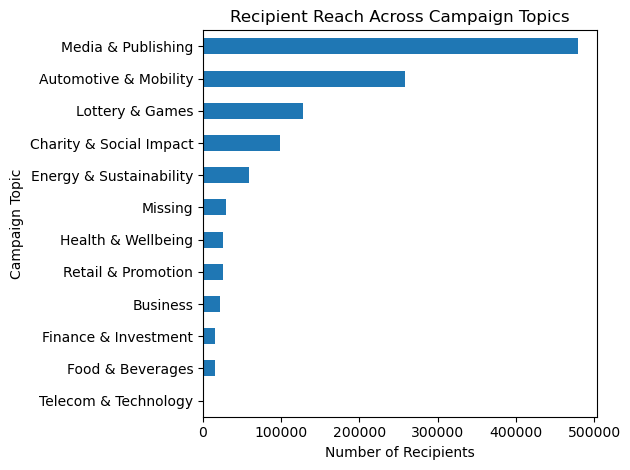

In [146]:
# plot

topic_exposure = topic_size['#user_exposures'].sort_values()

topic_exposure.plot(kind='barh')
plt.title('Recipient Reach Across Campaign Topics')
plt.xlabel('Number of Recipients')
plt.ylabel('Campaign Topic')
plt.tight_layout()
plt.show()

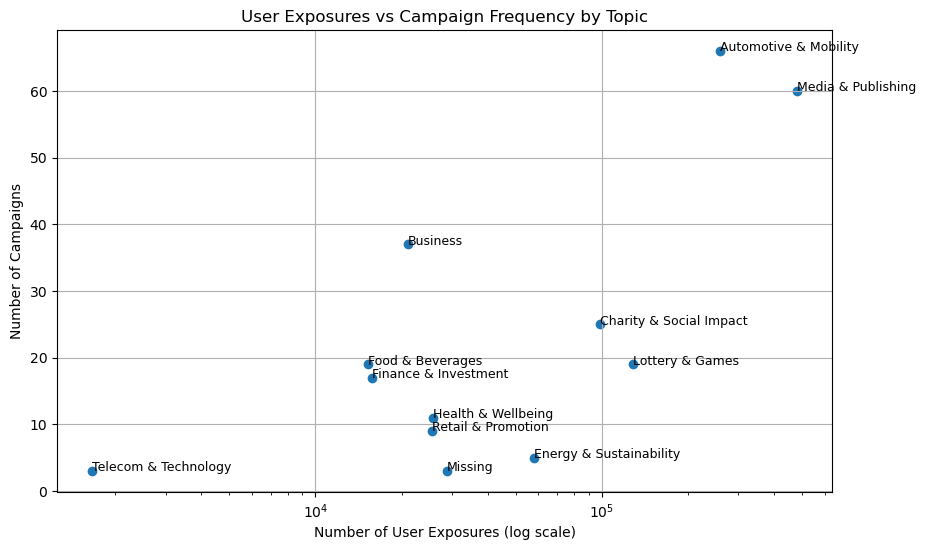

In [147]:
# scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    topic_size['#user_exposures'],
    topic_size['#campaigns'])

# labels
for topic, row in topic_size.iterrows():
    plt.text(
        row['#user_exposures'],
        row['#campaigns'],
        topic,
        fontsize=9)
    
# log scale for x axis
plt.xscale('log')

plt.title('User Exposures vs Campaign Frequency by Topic')
plt.xlabel('Number of User Exposures (log scale)')
plt.ylabel('Number of Campaigns')

plt.grid(True)

plt.show()

##### Insights
- Media & Publishing: dominates both campaign count and total user exposure -> core campaign topic in OMG
- Energy & Sustainability campaigns: relatively rare, largest average campaign size -> broad targeting strategy
- Business campaigns: high campaign frequency, small average campaign size -> niche/segmented targeting
- Automotive & Mobility: high campaign frequency, high total exposure 

### Topic x Engagement Analysis

#### Unweighted topic x engagement analysis (not account for number of user exposures)

In [148]:
print(df_final_topic['open'].value_counts(dropna = False))
print(df_final_topic['click'].value_counts(dropna = False))

open
1.0    567034
0.0    490510
NaN     98760
Name: count, dtype: int64
click
0.0    1103047
NaN      52062
1.0       1195
Name: count, dtype: int64


In [149]:
# campaign - open rate and click rate
campaign_performance = (
    df_final_topic.groupby(['mailing_id', 'main_topic']).agg({
        'open': 'mean',
        'click': 'mean'
    }).reset_index())

campaign_performance.head()

,mailing_id,main_topic,open,click
0,653,Finance & Investment,0.699396,0.000000
1,654,Finance & Investment,0.508661,0.001546
2,655,Finance & Investment,0.765385,0.000000
3,668,Media & Publishing,0.491019,0.000630
4,669,Media & Publishing,0.594220,0.000000


In [150]:
# topic - open and click rates
topic_performance = (
    campaign_performance.groupby('main_topic').agg({
        'open': ['mean', 'median'],
        'click': ['mean', 'median'],
        'mailing_id': 'count'
    }))

topic_performance

open               click           mailing_id
                             mean    median      mean    median      count
main_topic                                                                
Automotive & Mobility    0.570721  0.575073  0.001909  0.001177         66
Business                 0.486435  0.563460  0.000688  0.000000         37
Charity & Social Impact  0.596531  0.666667  0.028529  0.001010         25
Energy & Sustainability  0.485198  0.522585  0.000698  0.000684          5
Finance & Investment     0.398059  0.434109  0.001474  0.000569         17
Food & Beverages         0.475498  0.526646  0.000060  0.000000         19
Health & Wellbeing       0.502958  0.529412  0.000356  0.000000         11
Lottery & Games          0.560109  0.536790  0.014692  0.000458         19
Media & Publishing       0.546281  0.603324  0.005186  0.000340         60
Missing                  0.499877  0.680187  0.000340  0.000000          3
Retail & Promotion       0.507283  0.665373  0.000931  0.000557          9
Telecom & Technology     0.431894  0.527337  0.000000  0.000000          3

In [151]:
# topics with highest average open rate
topic_performance.sort_values(('open', 'mean'), ascending = False)

open               click           mailing_id
                             mean    median      mean    median      count
main_topic                                                                
Charity & Social Impact  0.596531  0.666667  0.028529  0.001010         25
Automotive & Mobility    0.570721  0.575073  0.001909  0.001177         66
Lottery & Games          0.560109  0.536790  0.014692  0.000458         19
Media & Publishing       0.546281  0.603324  0.005186  0.000340         60
Retail & Promotion       0.507283  0.665373  0.000931  0.000557          9
Health & Wellbeing       0.502958  0.529412  0.000356  0.000000         11
Missing                  0.499877  0.680187  0.000340  0.000000          3
Business                 0.486435  0.563460  0.000688  0.000000         37
Energy & Sustainability  0.485198  0.522585  0.000698  0.000684          5
Food & Beverages         0.475498  0.526646  0.000060  0.000000         19
Telecom & Technology     0.431894  0.527337  0.000000  0.000000          3
Finance & Investment     0.398059  0.434109  0.001474  0.000569         17

##### Insights
- Charity & Social Impact campaigns: highest average open rate (59.65%), highest median open rate (66.67%) -> consistenly attract user attention
- Automotive & Mobility campaigns: high average open rate across a large number of campaigns, mean ~ median (~57%) -> stable performance, consistently relevant to audience
- Media & Publishing campaigns: strong open rate, large number of campaigns -> increase reliability
- Finance & Investment campaigns: lowest average open rates (39.81%) -> low user interst or high informational complexity compared to others
- Topics with small campaign sizes (Telecom & Technology, Missing): unstable -> should not be generalised without additional data

In [152]:
# topics with highest average click rate
topic_performance[['click', 'open', 'mailing_id']].sort_values(('click', 'mean'), ascending = False)

click                open           mailing_id
                             mean    median      mean    median      count
main_topic                                                                
Charity & Social Impact  0.028529  0.001010  0.596531  0.666667         25
Lottery & Games          0.014692  0.000458  0.560109  0.536790         19
Media & Publishing       0.005186  0.000340  0.546281  0.603324         60
Automotive & Mobility    0.001909  0.001177  0.570721  0.575073         66
Finance & Investment     0.001474  0.000569  0.398059  0.434109         17
Retail & Promotion       0.000931  0.000557  0.507283  0.665373          9
Energy & Sustainability  0.000698  0.000684  0.485198  0.522585          5
Business                 0.000688  0.000000  0.486435  0.563460         37
Health & Wellbeing       0.000356  0.000000  0.502958  0.529412         11
Missing                  0.000340  0.000000  0.499877  0.680187          3
Food & Beverages         0.000060  0.000000  0.475498  0.526646         19
Telecom & Technology     0.000000  0.000000  0.431894  0.527337          3

##### Insights
- Charity & Social Impact campaigns: highest average click rate (2.85%) -> good at getting attention (highest open rate) and pushing users to interact
- Lottery & Games campaigns: usually have rewards/interactive hook -> perform well for clicks
- Media & Publishing campaigns: decent click performance, a large number of campaigns -> more reliable results
- Automotive & Mobility campaigns: strong open rates, much lower click rates -> users are curious to open but not motivated further
- Finance & Investment campaigns: lowest open rate, click rate is not lowest -> few people open, but who do open still have some interest
- Topics with small campaign sizes (Telecom & Technology, Missing): unstable -> should not be generalised without additional data

#### Weighted topic x engagement analysis (account for number of user exposures)

In [153]:
# topic - open and click rates (weighted)
weighted_topic_performance = (
    df_final_topic.groupby('main_topic').agg({
        'open': 'mean',
        'click': 'mean',
        'user_id': 'count'})
        .rename(columns = {
            'user_id': "#user_exposures",
            'open': 'open_weighted',
            'click': 'click_weighted'}))

weighted_topic_performance

,open_weighted,click_weighted,#user_exposures
main_topic,,,
Automotive & Mobility,0.597493,0.001675,257994
Business,0.560181,0.001023,21087
Charity & Social Impact,0.489127,0.002620,98333
Energy & Sustainability,0.499381,0.000685,58188
Finance & Investment,0.344169,0.001322,15722
Food & Beverages,0.546255,0.000070,15275
Health & Wellbeing,0.516609,0.000438,25822
Lottery & Games,0.531768,0.000901,128094
Media & Publishing,0.536876,0.000665,479712


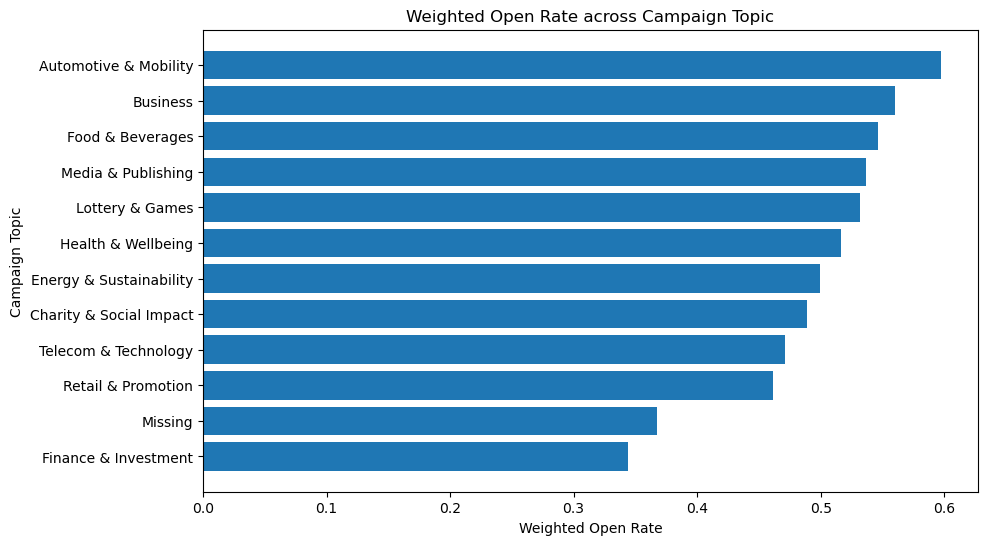

In [154]:
# sort by weighted open rate
open_plot = weighted_topic_performance.sort_values('open_weighted', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(open_plot.index, open_plot['open_weighted'])
plt.title('Weighted Open Rate across Campaign Topic')
plt.xlabel('Weighted Open Rate')
plt.ylabel('Campaign Topic')
plt.show()

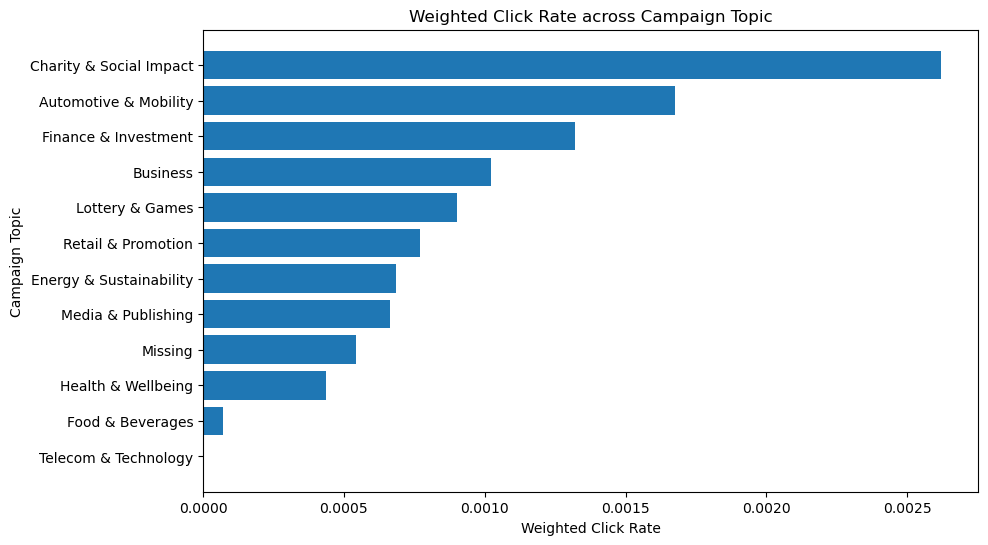

In [155]:
# sort by weighted click rate
click_plot = weighted_topic_performance.sort_values('click_weighted', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(click_plot.index, click_plot['click_weighted'])
plt.title('Weighted Click Rate across Campaign Topic')
plt.xlabel('Weighted Click Rate')
plt.ylabel('Campaign Topic')
plt.show()

In [156]:
# topics with highest average open rate (weighted)
weighted_topic_performance.sort_values('open_weighted', ascending = False)

,open_weighted,click_weighted,#user_exposures
main_topic,,,
Automotive & Mobility,0.597493,0.001675,257994
Business,0.560181,0.001023,21087
Food & Beverages,0.546255,0.000070,15275
Media & Publishing,0.536876,0.000665,479712
Lottery & Games,0.531768,0.000901,128094
Health & Wellbeing,0.516609,0.000438,25822
Energy & Sustainability,0.499381,0.000685,58188
Charity & Social Impact,0.489127,0.002620,98333
Telecom & Technology,0.470963,0.000000,1664


##### Insights (weighted analysis)
- Automotive & Mobility: top performing campaigns -> strong opens even at large audience scale
- Charity & Social Impact: drop noticeably (despite first ranking in unweighted) -> unweighted performance may come from smaller campaigns
- Business: perform better -> larger business-related campaigns achieve stronger open rates
- Media & Publishing: consistenly strong opens, largest number of users -> stable open behaviour at scale
- Finance & Investment: weakest -> consistenly low open engagement across campaigns and user exposures


In [157]:
# topics with highest average click rate (weighted)
weighted_topic_performance.sort_values('click_weighted', ascending = False)

,open_weighted,click_weighted,#user_exposures
main_topic,,,
Charity & Social Impact,0.489127,0.002620,98333
Automotive & Mobility,0.597493,0.001675,257994
Finance & Investment,0.344169,0.001322,15722
Business,0.560181,0.001023,21087
Lottery & Games,0.531768,0.000901,128094
Retail & Promotion,0.461394,0.000772,25563
Energy & Sustainability,0.499381,0.000685,58188
Media & Publishing,0.536876,0.000665,479712
Missing,0.367773,0.000544,28850


##### Insights (weighted analysis)
- Finance & Investment: higher click ranking -> larger finance-related campaigns generate strong clicks
- Charity & Social Impact: still highest clicks -> scale relatively well across larger audience exposures
- Media & Publishing: drops noticeably, extremely large exposure -> broad audience not necessarily translate into strong clicks
- Automotive & Mobility: remains strong -> stable performance at scale
- Food & Beverages: weak clicks, moderate opens -> no further action after opening

## Topic x User Analysis

In [158]:
# merge topic dataset and user dataset
df_final_topic = df_final_topic.merge(
    df_user_clean[['user_id', 'open_segment', 'click_segment']],
    on = 'user_id',
    how = 'left')

df_final_topic[['user_id', 'main_topic', 'open_segment', 'click_segment']].head()

,user_id,main_topic,open_segment,click_segment
0,5cb9a38136dd1336b9c528d1,Media & Publishing,low_open,no_click
1,5cb9a38136dd1336b9c528d1,Media & Publishing,low_open,no_click
2,5cb9a38136dd1336b9c528d1,Energy & Sustainability,low_open,no_click
3,5cb9a38136dd1336b9c528d1,Lottery & Games,low_open,no_click
4,5cb9a38136dd1336b9c528d1,Energy & Sustainability,low_open,no_click


### Topic x Engagement segmentation Analysis

In [159]:
# topic distribution by opens
topic_open_segment = pd.crosstab(
    df_final_topic['main_topic'],
    df_final_topic['open_segment'],
    normalize = 'columns')

# difference between high and low open column
topic_open_segment['open_difference'] = (topic_open_segment['high_open'] - topic_open_segment['low_open'])

# sort by difference
topic_open_segment.reindex(topic_open_segment['open_difference'].abs().sort_values(ascending = False).index)

open_segment,high_open,low_open,open_difference
main_topic,,,
Automotive & Mobility,0.248714,0.216269,0.032445
Charity & Social Impact,0.076541,0.090652,-0.014111
Energy & Sustainability,0.043613,0.053972,-0.010358
Lottery & Games,0.102460,0.112816,-0.010356
Media & Publishing,0.417995,0.408146,0.009849
Finance & Investment,0.009477,0.016245,-0.006768
Missing,0.025784,0.024811,0.000973
Telecom & Technology,0.000861,0.001596,-0.000735
Business,0.017368,0.018042,-0.000674


##### Insights
- Automotive & Mobility: largest positive difference (3.24%) -> appear relatively more among high-open users
- Media & Publishing: small positive difference -> associciate slightly stronger with high-open users
- Charity & Social Impact, Energy & Sustainability, Lottery & Games: appear relatively more among low-open users (differences not large though)
- Differences across topics are relatively modest -> user open behaviour may depend more on other factors

In [160]:
# topic distribution by clicks
topic_click_segment = pd.crosstab(
    df_final_topic['main_topic'],
    df_final_topic['click_segment'],
    normalize = 'columns')

# difference between high and low open column
topic_click_segment['click_difference'] = (topic_click_segment['click'] - topic_click_segment['no_click'])

# sort by strongest difference
topic_click_segment.reindex(topic_click_segment['click_difference'].abs().sort_values(ascending = False).index)

click_segment,click,no_click,click_difference
main_topic,,,
Media & Publishing,0.377422,0.413457,-0.036035
Automotive & Mobility,0.258391,0.232107,0.026284
Lottery & Games,0.093945,0.107823,-0.013879
Charity & Social Impact,0.096021,0.083489,0.012531
Finance & Investment,0.024913,0.012740,0.012174
Business,0.025433,0.017617,0.007815
Health & Wellbeing,0.015052,0.022600,-0.007548
Retail & Promotion,0.017993,0.021903,-0.003910
Food & Beverages,0.015138,0.012923,0.002216


##### Insights
- Media & Publishing: strongly represent low-click users (-3.6%) -> achieve good opens, but may not convert into deeper engagement
- Automotive & Mobility: strong positive difference (2.6%) -> users more likely to click after opening
- Charity & Social Impact and Finance & Investment: positive click differencess -> drive more clicking
- Lottery & Games: decent open behaviour but worse in click behaviour -> curiosity-driven opens but weaker post-open engagement
- Compared to open bahaviour, topic differences are more pronounced for click behaviour -> campaign topic may have stronger influence on clicks

## Topic x Gender Analysis

### Topic distribution by gender

In [161]:
# topic distribution by gender
topic_gender = pd.crosstab(
    df_final_topic['main_topic'],
    df_final_topic['gender'],
    normalize = 'columns'
)

In [162]:
# male vs female difference
topic_gender['distribution_difference'] = (topic_gender['female'] - topic_gender['male'])

# sort by strongest difference
topic_gender = topic_gender.reindex(topic_gender['distribution_difference'].abs().sort_values(ascending = False).index)

topic_gender

gender,female,male,other,distribution_difference
main_topic,,,,
Automotive & Mobility,0.209713,0.242640,0.172489,-0.032927
Lottery & Games,0.115163,0.104400,0.127229,0.010763
Health & Wellbeing,0.026217,0.017452,0.019469,0.008765
Media & Publishing,0.417920,0.409508,0.446961,0.008412
Food & Beverages,0.014051,0.011999,0.016103,0.002052
Energy & Sustainability,0.050971,0.049344,0.053539,0.001627
Charity & Social Impact,0.085431,0.084349,0.089292,0.001082
Business,0.017889,0.018842,0.014693,-0.000954
Finance & Investment,0.013879,0.013389,0.010098,0.000490


##### Insights
- Automotive & Mobility: strongest gender distribution imbalance, male users receieve more than female
- Lottery & Games, Health & Wellbeing, Media & Publishing: slightly more represented among female
- Most remaining topics: relatively balanced gender distribution

### Topic x Gender Engagement Analysis

In [163]:
df_final_topic['gender'].value_counts(dropna = False)

gender
female    638677
male      495643
other      21984
Name: count, dtype: int64

In [164]:
# engagement rates by topic and gender
topic_gender_engagement = (df_final_topic.groupby(['main_topic', 'gender']).agg({
    'open': 'mean',
    'click': 'mean'}).reset_index())

topic_gender_engagement.head()

,main_topic,gender,open,click
0,Automotive & Mobility,female,0.591518,0.001125
1,Automotive & Mobility,male,0.604095,0.002325
2,Automotive & Mobility,other,0.598853,0.000836
3,Business,female,0.571058,0.000752
4,Business,male,0.547780,0.001394


In [165]:
# pivot open rate
topic_gender_open = topic_gender_engagement.pivot(
    index = 'main_topic',
    columns = 'gender',
    values = 'open'
)

topic_gender_open

gender,female,male,other
main_topic,,,
Automotive & Mobility,0.591518,0.604095,0.598853
Business,0.571058,0.547780,0.536667
Charity & Social Impact,0.494977,0.480299,0.512577
Energy & Sustainability,0.506719,0.488758,0.515123
Finance & Investment,0.353089,0.332782,0.333333
Food & Beverages,0.560779,0.519143,0.633136
Health & Wellbeing,0.524900,0.498516,0.553525
Lottery & Games,0.538711,0.520468,0.554183
Media & Publishing,0.538215,0.534073,0.557865


In [166]:
# female vs male difference
topic_gender_open['open_difference'] = (topic_gender_open['female'] - topic_gender_open['male'])

# sort by strongest difference
topic_gender_open = topic_gender_open.reindex(topic_gender_open['open_difference'].abs().sort_values(ascending = False).index)

topic_gender_open

gender,female,male,other,open_difference
main_topic,,,,
Telecom & Technology,0.509918,0.414634,0.318182,0.095284
Food & Beverages,0.560779,0.519143,0.633136,0.041636
Health & Wellbeing,0.524900,0.498516,0.553525,0.026384
Business,0.571058,0.547780,0.536667,0.023278
Finance & Investment,0.353089,0.332782,0.333333,0.020307
Lottery & Games,0.538711,0.520468,0.554183,0.018243
Energy & Sustainability,0.506719,0.488758,0.515123,0.017960
Charity & Social Impact,0.494977,0.480299,0.512577,0.014678
Automotive & Mobility,0.591518,0.604095,0.598853,-0.012577


##### Insights
- Female users shows slightly higher open rates across most topics
- Largest gender gap in Telecom & Technology (female > male), but a small number of user exposures -> should be interpreted cautiously
- Food & Beverages and Health & Wellbeing: moderately stronger open rates among female
- Automotive & Mobility: one of the few where male outperform female
- Most gaps remain small -> open behaviour is broadly similar across genders

In [167]:
# pivot click rate
topic_gender_click = topic_gender_engagement.pivot(
    index = 'main_topic',
    columns = 'gender',
    values = 'click'
)

topic_gender_click

gender,female,male,other
main_topic,,,
Automotive & Mobility,0.001125,0.002325,0.000836
Business,0.000752,0.001394,0.000000
Charity & Social Impact,0.002584,0.002794,0.000000
Energy & Sustainability,0.000319,0.001213,0.000000
Finance & Investment,0.000737,0.002157,0.000000
Food & Beverages,0.000119,0.000000,0.000000
Health & Wellbeing,0.000000,0.001312,0.000000
Lottery & Games,0.000927,0.000914,0.000000
Media & Publishing,0.000485,0.000937,0.000000


In [168]:
# female vs male difference
topic_gender_click['click_difference'] = (topic_gender_click['female'] - topic_gender_click['male'])

# sort by strongest difference
topic_gender_click = topic_gender_click.reindex(topic_gender_click['click_difference'].abs().sort_values(ascending = False).index)

topic_gender_click

gender,female,male,other,click_difference
main_topic,,,,
Finance & Investment,0.000737,0.002157,0.000000,-0.001420
Health & Wellbeing,0.000000,0.001312,0.000000,-0.001312
Automotive & Mobility,0.001125,0.002325,0.000836,-0.001200
Retail & Promotion,0.000291,0.001445,0.000000,-0.001155
Energy & Sustainability,0.000319,0.001213,0.000000,-0.000894
Missing,0.000196,0.001025,0.000000,-0.000830
Business,0.000752,0.001394,0.000000,-0.000641
Media & Publishing,0.000485,0.000937,0.000000,-0.000452
Charity & Social Impact,0.002584,0.002794,0.000000,-0.000210


##### Insights
- Male users show higher click rates across most topics, despite female users often show higher open rates
- Finance & Investment, Health & Wellbeing, Automotive & Mobility: strong male click advantages
- Male users may be more likely to click after opening for certain topics
- Food & Beverages shows higher click rate among female (though difference is small)
- Low click rates across all topics -> Modest gender differences in click behaviour

## Topic x Age Analysis

In [169]:
# keep realistic ages only (18-90)
df_age = df_final_topic[
    (df_final_topic['age'] >= 18) &
    (df_final_topic['age'] <= 90)].copy()

# create age groups
df_age['age_group'] = pd.cut(
    df_age['age'],
    bins = [18, 35, 50, 65, 90],
    labels = ['18-35', '35-50', '50-65', '65+'])

In [170]:
# remove missing age
df_age = df_age.dropna(subset = ['age'])

In [171]:
df_age['age_group'].value_counts(normalize = True)

age_group
35-50    0.317460
50-65    0.308369
65+      0.243186
18-35    0.130986
Name: proportion, dtype: float64

##### Insight
- Dataset is skewed toward older users
- Users aged 35-65 make up ~62% of population
- Users aged 18-35 account for ~ 13%

### Topic distribution by age group

In [172]:
# topic distribution by age group
topic_age = pd.crosstab(
    df_age['main_topic'],
    df_age['age_group'],
    normalize = 'columns')

topic_age

age_group,18-35,35-50,50-65,65+
main_topic,,,,
Automotive & Mobility,0.173963,0.208131,0.235511,0.255302
Business,0.021066,0.021698,0.018837,0.017714
Charity & Social Impact,0.070435,0.081512,0.090413,0.093077
Energy & Sustainability,0.047978,0.051068,0.055921,0.056429
Finance & Investment,0.011950,0.014016,0.016912,0.019947
Food & Beverages,0.014757,0.014940,0.012996,0.013982
Health & Wellbeing,0.067396,0.035725,0.022863,0.004730
Lottery & Games,0.116920,0.114941,0.110300,0.108238
Media & Publishing,0.424672,0.411767,0.391220,0.385319


##### Insights
- Automotive & Mobility, Finance & Investment: more represented in older age groups -> targeted more heavily toward older users
- Media & Publishing, Health & Wellbeing: decling representation with age -> stronger exposure among younger users
- Most other topics: stable distributions acros age groups

### Topic x Age Engagement Analysis

In [173]:
# engagement rates by topic, age groups
topic_age_engagement = (
    df_age.groupby(['main_topic', 'age_group']).agg({
        'open': 'mean',
        'click': 'mean'}).reset_index())

topic_age_engagement.head()

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/4147856834.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_age.groupby(['main_topic', 'age_group']).agg({


,main_topic,age_group,open,click
0,Automotive & Mobility,18-35,0.723012,0.000000
1,Automotive & Mobility,35-50,0.638601,0.000312
2,Automotive & Mobility,50-65,0.529484,0.001752
3,Automotive & Mobility,65+,0.475082,0.003149
4,Business,18-35,0.692994,0.000000


In [174]:
# pivot open rate
topic_age_open = topic_age_engagement.pivot(
    index = 'main_topic',
    columns = 'age_group',
    values = 'open')

In [175]:
# youngest vs oldest open rate difference
topic_age_open['open_difference'] = (topic_age_open['18-35'] - topic_age_open['65+'])

# sort by strongest difference
topic_age_open = topic_age_open.reindex(topic_age_open['open_difference'].abs().sort_values(ascending = False).index)

topic_age_open

age_group,18-35,35-50,50-65,65+,open_difference
main_topic,,,,,
Telecom & Technology,0.833333,0.505263,0.435897,0.348993,0.484340
Food & Beverages,0.676786,0.563150,0.507136,0.405048,0.271738
Automotive & Mobility,0.723012,0.638601,0.529484,0.475082,0.247930
Business,0.692994,0.574074,0.465179,0.454294,0.238700
Lottery & Games,0.622935,0.571086,0.454323,0.421725,0.201211
Media & Publishing,0.615212,0.560456,0.457056,0.415139,0.200073
Energy & Sustainability,0.609447,0.571695,0.416837,0.411196,0.198251
Charity & Social Impact,0.590101,0.549211,0.417886,0.402311,0.187790
Health & Wellbeing,0.616505,0.518777,0.361466,0.450000,0.166505


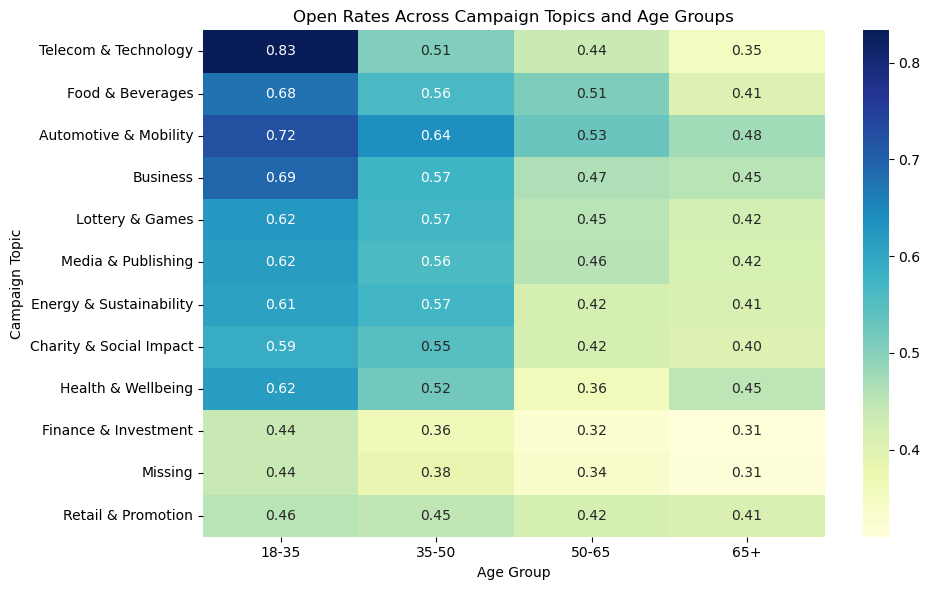

In [176]:
# remove the difference column for heatmap
heatmap_data = topic_age_open.drop(columns = ['open_difference'])

# create figure
plt.figure(figsize = (10, 6))

# heatmap
sns.heatmap(
    heatmap_data,
    annot = True,
    fmt = '.2f',
    cmap = 'YlGnBu'
)

# titles and labels
plt.title('Open Rates Across Campaign Topics and Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Campaign Topic')

plt.tight_layout()
plt.show()

##### Insights
- Open rates generally decline with age across most topics
- Telecom & Technology: strongest age difference (~48%)
- Food & Beverages, Automotive & Mobility, Business: substantial age differences (>20%)
- Retail & Promotion: stable across age groups
- Certain campaign topics may resonate more strongly with younger audiences (technology-related, consumer-focused)
- However, some topics (eg. Telecom & Technology) contained few campaigns and user exposures -> interpreted cautiously

In [177]:
# pivot click rate
topic_age_click = topic_age_engagement.pivot(
    index = 'main_topic',
    columns = 'age_group',
    values = 'click')

In [178]:
# youngest vs oldest click rate difference
topic_age_click['click_difference'] = (topic_age_click['18-35'] - topic_age_click['65+'])

# sort by strongest difference
topic_age_click = topic_age_click.reindex(topic_age_click['click_difference'].abs().sort_values(ascending = False).index)

topic_age_click

age_group,18-35,35-50,50-65,65+,click_difference
main_topic,,,,,
Finance & Investment,0.0,0.000000,0.000000,0.010178,-0.010178
Charity & Social Impact,0.0,0.000000,0.004836,0.009607,-0.009607
Automotive & Mobility,0.0,0.000312,0.001752,0.003149,-0.003149
Lottery & Games,0.0,0.000000,0.001238,0.003119,-0.003119
Energy & Sustainability,0.0,0.000000,0.000819,0.001935,-0.001935
Media & Publishing,0.0,0.000000,0.001341,0.001368,-0.001368
Missing,0.0,0.000000,0.000453,0.001195,-0.001195
Retail & Promotion,0.0,0.000000,0.003213,0.000954,-0.000954
Business,0.0,0.000000,0.000000,0.000000,0.000000


##### Insights
- Click behaviour increases with age (unlike open)
- 18-35 group generated no recorded clicks
- Click rates rise progressively across older age groups
- Click activity is extremely sparse overall -> click-based age patterns should be interpreted cautiously

In [179]:
print(df_age.groupby('age_group')['click'].sum())
print(df_age.groupby('age_group')['click'].mean())

age_group
18-35      0.0
35-50     12.0
50-65    142.0
65+      186.0
Name: click, dtype: float64
age_group
18-35    0.000000
35-50    0.000130
50-65    0.001624
65+      0.002916
Name: click, dtype: float64


/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/3775987239.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_age.groupby('age_group')['click'].sum())
/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/3775987239.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_age.groupby('age_group')['click'].mean())


## Interest relevance analysis

In [180]:
df_final_topic.columns

Index(['user_id', 'gender', 'birth_date', 'postcode', 'city', 'interests',
       'age', 'n_interests', 'open_type', 'click_type', 'mailing_id', 'open',
       'click', 'mailing_info', 'subject_line', 'preheader', 'main_topic',
       'open_segment', 'click_segment'],
      dtype='object')

In [181]:
df_final_topic.head()

,user_id,gender,birth_date,postcode,city,interests,age,n_interests,open_type,click_type,mailing_id,open,click,mailing_info,subject_line,preheader,main_topic,open_segment,click_segment
0,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,668,0.0,0.0,2025/04/24 CPX - MM MAX Magazine - 4 gratis nrs,"Lezen, puzzelen, genieten: 4 edities cadeau","Vraag nu aan – geen kosten, geen verplichtingen.",Media & Publishing,low_open,no_click
1,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,692,0.0,0.0,2025/05/29 DPG 4W1E,4 weken jouw favoriete krant digitaal voor maa...,"Toegang tot AD, de Volkskrant, Trouw en meer v...",Media & Publishing,low_open,no_click
2,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,714,0.0,0.0,2025/05/06 CPX - MM - ENGIE BONUS,Profiteer nu: €300 bonus én vaste energietarieven,ENGIE helpt je graag met persoonlijk advies.,Energy & Sustainability,low_open,no_click
3,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,733,0.0,0.0,2025/05/14 LIFEPOINTS,Jouw mening is geld waard – start vandaag nog,Verdien punten voor digitale cadeaubonnen zoal...,Lottery & Games,low_open,no_click
4,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,761,0.0,0.0,2025/05/27 CPX - MM - ENGIE,Speel mee met de ENGIE woordlegger!,"En win een solar powerbank t.w.v. €79,95.",Energy & Sustainability,low_open,no_click


In [182]:
# interests dictionary
interest_topic_map = {
    # automotive
    'auto': 'Automotive & Mobility',
    'cx80': 'Automotive & Mobility',
    'auto inruilen': 'Automotive & Mobility',
    'mazda': 'Automotive & Mobility',
    'elektrisch': 'Automotive & Mobility',
    'audi': 'Automotive & Mobility',
    'mazda6e': 'Automotive & Mobility',
    'dacia': 'Automotive & Mobility',
    'hybrid': 'Automotive & Mobility',
    'mercedes': 'Automotive & Mobility',
    'toyota': 'Automotive & Mobility',
    'lease': 'Automotive & Mobility',
    'cx60': 'Automotive & Mobility',
    'cx5': 'Automotive & Mobility',
    'mx30': 'Automotive & Mobility',
    'cx30': 'Automotive & Mobility',
    'hyundai': 'Automotive & Mobility',
    'bedrijfswagen': 'Automotive & Mobility',
    'porsche': 'Automotive & Mobility',


    # business
    'mkb': 'Business',
    'ondernemers': 'Business',
    'zakelijk rijden': 'Business',
    'hr': 'Business',
    'bedrijven': 'Business',
    'zzp': 'Business',

    # charity
    'goededoelen': 'Charity & Social Impact',

    # energy
    'energie': 'Energy & Sustainability',

    # finance
    'verzekering': 'Finance & Investment',
    'bank': 'Finance & Investment',
    'beleggen': 'Finance & Investment',
    'finance': 'Finance & Investment',
    'hypotheek': 'Finance & Investment',
    'centraal beheer': 'Finance & Investment',
    'belastingdienst': 'Finance & Investment',

    # food
    'bezorgmaaltijden': 'Food & Beverages',
    'horeca': 'Food & Beverages',

    # health
    'zorg': 'Health & Wellbeing',

    # lottery
    'kansspelen': 'Lottery & Games',
    'loterij': 'Lottery & Games',
    'winactie': 'Lottery & Games',

    # media
    'bladen': 'Media & Publishing',
    'kranten': 'Media & Publishing',
    'entertainment': 'Media & Publishing',
    'onderzoek': 'Media & Publishing',

    # retail
    'cadeau': 'Retail & Promotion',
    'acties': 'Retail & Promotion',
    'kortingen': 'Retail & Promotion',

    # tech
    'windows': 'Telecom & Technology',
    'it': 'Telecom & Technology',
    'telcom': 'Telecom & Technology',
    'ios': 'Telecom & Technology',
    'android': 'Telecom & Technology',
    'linux': 'Telecom & Technology',
    'chrome os': 'Telecom & Technology',
    'mac os': 'Telecom & Technology',
    'os x': 'Telecom & Technology',


    #other
    'bigevent': 'Other',
    'wetgeving': 'Other',
    'overheid': 'Other',

    #unknown
    'unknown': 'Unknown'
}

In [183]:
# function to map interest
def map_interest(x):

    # missing values
    if pd.isna(x):
        return 'Missing'
    
    # mapped interest
    return interest_topic_map.get(x, 'Other')


In [184]:
# apply mapping to interests dataset
df_interests['mapped_interest_topic'] = df_interests['interests'].apply(map_interest)

df_interests[[ 'interests', 'mapped_interest_topic']].head()

,interests,mapped_interest_topic
0,auto,Automotive & Mobility
0,loterij,Lottery & Games
0,kranten,Media & Publishing
0,entertainment,Media & Publishing
0,winactie,Lottery & Games


In [185]:
df_interests['mapped_interest_topic'].value_counts(normalize = True)

mapped_interest_topic
Automotive & Mobility      0.312437
Media & Publishing         0.151085
Retail & Promotion         0.132866
Lottery & Games            0.086696
Finance & Investment       0.084470
Business                   0.075345
Energy & Sustainability    0.042083
Charity & Social Impact    0.038892
Unknown                    0.030886
Other                      0.023634
Telecom & Technology       0.015039
Food & Beverages           0.005387
Health & Wellbeing         0.001117
Missing                    0.000062
Name: proportion, dtype: float64

In [186]:
# groupby user id, each user with a list of mapped topics
user_interest_topics = (df_interests.groupby('user_id')['mapped_interest_topic'].apply(list).reset_index())

# merge mapped user interests into final topic dataset
df_final_topic = df_final_topic.merge(
    user_interest_topics,
    on = 'user_id',
    how = 'left')

In [187]:
df_final_topic['mapped_interest_topic'].head()

0    [Energy & Sustainability, Lottery & Games, Med...
1    [Energy & Sustainability, Lottery & Games, Med...
2    [Energy & Sustainability, Lottery & Games, Med...
3    [Energy & Sustainability, Lottery & Games, Med...
4    [Energy & Sustainability, Lottery & Games, Med...
Name: mapped_interest_topic, dtype: object

In [188]:
# match campaigns with interests function, 1 if campaign topic in user interests, 0 otherwise
def check_interest_match(row):
    interests = row['mapped_interest_topic']

    if not isinstance(interests, list):
        return 0
    
    return 1 if row['main_topic'] in interests else 0

df_final_topic['interest_topic_match'] = df_final_topic.apply(check_interest_match, axis = 1)

In [189]:
df_final_topic['interest_topic_match'].value_counts(normalize=True)

interest_topic_match
1    0.806709
0    0.193291
Name: proportion, dtype: float64

In [190]:
# engagement rate on interest match
df_final_topic.groupby('interest_topic_match')[['open', 'click']].mean()

,open,click
interest_topic_match,,
0,0.351875,0.001073
1,0.560827,0.001084


##### Insights
- Campaigns whose topics aligned with user interests achieved substantially higher open rates -> topic alignment strongly influences whether users open email
- Click rates remained almost identical (~0.11%) -> interest alignment may encourage users to open emails, but not translate click behaviour

## Subject line - Preheader Analysis

### Subject line Analysis

In [191]:
df_content = df_final_topic.copy()

In [192]:
df_content.columns

Index(['user_id', 'gender', 'birth_date', 'postcode', 'city', 'interests',
       'age', 'n_interests', 'open_type', 'click_type', 'mailing_id', 'open',
       'click', 'mailing_info', 'subject_line', 'preheader', 'main_topic',
       'open_segment', 'click_segment', 'mapped_interest_topic',
       'interest_topic_match'],
      dtype='object')

#### Length

In [193]:
df_subject = df_content.copy()

# remove missing subject lines
df_subject = df_subject[df_subject['subject_line'].notna()]

# remove empty strings
df_subject = df_subject[df_subject['subject_line'].str.strip() != '']

In [194]:
# length of subject lines
df_subject['subject_length'] = (df_subject['subject_line'].str.len())

In [195]:
df_subject['subject_length'].describe()

count    1.127454e+06
mean     4.512420e+01
std      8.856277e+00
min      2.300000e+01
25%      3.900000e+01
50%      4.400000e+01
75%      4.900000e+01
max      9.300000e+01
Name: subject_length, dtype: float64

##### Insights
- No suspiciously short subject lines (min = 23)
- Campaigns centered around medium-length subjects (median = 44)
- Most subjects under 50 characters (75th quantile = 49)
- Some long subjects but not absurb (max = 93)

In [196]:
# create length buckets
df_subject['subject_length_group'] = pd.cut(
    df_subject['subject_length'],
    bins = [0, 35, 45, 55, 100],
    labels = ['short', 'medium', 'long', 'very_long']
)

In [197]:
# engagement rates based on length
df_subject.groupby('subject_length_group')[['open', 'click']].mean()

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/553857084.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_subject.groupby('subject_length_group')[['open', 'click']].mean()


,open,click
subject_length_group,,
short,0.360696,0.001234
medium,0.573273,0.001194
long,0.541186,0.000805
very_long,0.574964,0.001387


In [198]:
df_subject['subject_length_group'].value_counts(normalize = True)

subject_length_group
medium       0.445663
long         0.323267
very_long    0.121018
short        0.110051
Name: proportion, dtype: float64

##### Insights
- Short subject lines (< 35 characters) achieved low open rate (~36%)
- Medium, long, very long subject lones all performed better (~54-57% open rate)
-> Short subject lines may provide insufficient info or value to encourage users to open email
- Click rates show smaller differences across different length groups (compared to open rates)
- Very long subject lines achieved highest click rate
-> Subject line length influence open behaviour more strongly than click behaviour

#### Contain numbers?

##### Remark
Numerical elements does not distinguish between promotional numbers (eg. discounts) and product/model identifiers (eg. Mazda CX80) -> observed effect may reflect multiple underlying mechanisms

In [199]:
# check if contain numbers
df_subject['subject_contains_number'] = (df_subject['subject_line'].str.contains(r'\d', regex = True))

In [200]:
# engagement rate
df_subject.groupby('subject_contains_number')[['open', 'click']].mean()

,open,click
subject_contains_number,,
False,0.534092,0.001160
True,0.546353,0.001039


In [201]:
df_subject['subject_contains_number'].value_counts(normalize = True)

subject_contains_number
True     0.525961
False    0.474039
Name: proportion, dtype: float64

##### Insights
- Campaigns contain numbers in subject lines achieved slight higher open rate, but lower open rate -> numeric info may help attract user attention, but not necessarily translate into stronger engagement
- Campaigns contain numbers represented a slight majority of dataset -> numeric elements are common in subject lines

#### Contain exclamation marks?

In [202]:
# check if contain exclamation marks
df_subject['subject_contains_exclamation'] = (df_subject['subject_line'].str.contains('!', regex = False))

In [203]:
# engagement rate
df_subject.groupby('subject_contains_exclamation')[['open', 'click']].mean()

,open,click
subject_contains_exclamation,,
False,0.536614,0.001182
True,0.561049,0.000656


In [204]:
df_subject['subject_contains_exclamation'].value_counts(normalize = True)

subject_contains_exclamation
False    0.837923
True     0.162077
Name: proportion, dtype: float64

##### Insights
- Campaigns contain exclamation marks achieved slightly higher open rate -> exclamation marks may help increase visibility or attract user attention
- Campaigns contain exclamation marks showed a substantially lower click rate -> exclamation marks may not effectively translate into click behaviour
- Only around 16.2% campaigns contained exclamation marks -> used selective rather than as a dominant strategy

#### Contain promotional words?

##### Remark
Promotion feature was constructed using a predefined keyword list and may not capture all forms of promotional content

In [205]:
promotion_words = [
    'korting',
    'gratis',
    'cadeau',
    'aanbieding',
    'deal',
    'voordeel',
    'win',
    'actie',
    'bonus',
    'besparen'
]

In [206]:
# check if contain promotion words
promotion_pattern = '|'.join(promotion_words)

df_subject['subject_contains_promotion'] = (df_subject['subject_line'].str.lower().str.contains(promotion_pattern, regex = True))

In [207]:
# engagement rate
df_subject.groupby('subject_contains_promotion')[['open', 'click']].mean()

,open,click
subject_contains_promotion,,
False,0.538188,0.001100
True,0.557954,0.001065


In [208]:
df_subject['subject_contains_promotion'].value_counts(normalize = True)

subject_contains_promotion
False    0.879899
True     0.120101
Name: proportion, dtype: float64

##### Insights
- Campaign contain promotional languages achieved a slightly higher open rate -> promotional wording may help attract initial user attention
- Campaign contain promotional languages showed lower click rate -> promotional wording may not translate into stronger clicks
- 12% campaigns contained promotional keywords -> used selectively

### Preheader Analysis

In [209]:
df_preheader = df_final_topic.copy()

# remove missing values
df_preheader = df_preheader[df_preheader['preheader'].notna()]

# remove empty string
df_preheader = df_preheader[df_preheader['preheader'].str.strip() != '']

#### Length

In [210]:
# length of preheader
df_preheader['preheader_length'] = (df_preheader['preheader'].str.len())

In [211]:
df_preheader['preheader_length'].describe()

count    1.121945e+06
mean     5.746832e+01
std      1.139753e+01
min      2.900000e+01
25%      5.000000e+01
50%      5.700000e+01
75%      6.400000e+01
max      9.300000e+01
Name: preheader_length, dtype: float64

In [212]:
# create length buckets
df_preheader['preheader_length_group'] = pd.cut(
    df_preheader['preheader_length'],
    bins =[0, 45, 55, 65, 100],
    labels = ['short', 'medium', 'long', 'very_long'])

In [213]:
# engagement rate based on length
df_preheader.groupby('preheader_length_group')[['open', 'click']].mean()

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/650925492.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_preheader.groupby('preheader_length_group')[['open', 'click']].mean()


,open,click
preheader_length_group,,
short,0.566241,0.001140
medium,0.538179,0.000876
long,0.527130,0.001234
very_long,0.556577,0.001118


In [214]:
df_preheader['preheader_length_group'].value_counts(normalize = True)

preheader_length_group
long         0.361977
medium       0.302961
very_long    0.177919
short        0.157143
Name: proportion, dtype: float64

##### Insights
- Preheader length showed relatively limited variation in engagement rates (compared to subject line length)
- Open rates across all length groups remained similar (~52-57%)
-> Preheader length alone may not strongly influence user engagement behaviour -> preheaders support contextual text rather than drive attention
- Click rates show small differences across length groups

#### Contain numbers?

In [215]:
# check if contain numbers
df_preheader['preheader_contains_number'] = (df_subject['preheader'].str.contains(r'\d', regex = True))

In [216]:
# engagement rate
df_preheader.groupby('preheader_contains_number')[['open', 'click']].mean()

,open,click
preheader_contains_number,,
False,0.510882,0.001023
True,0.574823,0.001161


In [217]:
df_preheader['preheader_contains_number'].value_counts(normalize = True)

preheader_contains_number
False    0.515063
True     0.484937
Name: proportion, dtype: float64

##### Insights
- Campaigns contain numbers in preheader achieved higher engagement across both metrics -> positive relationship with opens and clicks
- Numeric info may help reinforce the perceived value of email content after users view inbox preview
- Preheader with numeric info are common but not dominant

#### Contain exclamation marks?

In [218]:
# check if contain exclamation marks
df_preheader['preheader_contains_exclamation'] = (df_preheader['preheader'].str.contains('!', regex = False))

In [219]:
# engagement rate
df_preheader.groupby('preheader_contains_exclamation')[['open', 'click']].mean()

,open,click
preheader_contains_exclamation,,
False,0.539214,0.001065
True,0.616961,0.001790


In [220]:
df_preheader['preheader_contains_exclamation'].value_counts(normalize = True)

preheader_contains_exclamation
False    0.9652
True     0.0348
Name: proportion, dtype: float64

##### Insights
- Campaigns contain exclamation marks achieved substantially higher engagement across both metrics -> exclamation marks may be more effective when used within preheader
- Only around 3.5% campaigns contained exclamation marks -> observed relationship should be interpreted cautiously

#### Contain promotional words

In [221]:
# check if contain promotion words
df_preheader['preheader_contains_promotion'] = (df_preheader['preheader'].str.lower().str.contains(promotion_pattern, regex = True))

In [222]:
# engagement rate
df_preheader.groupby('preheader_contains_promotion')[['open', 'click']].mean()

,open,click
preheader_contains_promotion,,
False,0.538347,0.001049
True,0.553689,0.001223


In [223]:
df_preheader['preheader_contains_promotion'].value_counts(normalize = True)

preheader_contains_promotion
False    0.763013
True     0.236987
Name: proportion, dtype: float64

##### Insights
- Campaigns contain prmotional language achieved higher engagement across both metrics -> positive relationship with opens and clicks
- ~24% campaigns contained promotional wording -> relatively common

### Observed Campaign Reach

In [ ]:
# campaign reach
campaign_reach = (
    df_final_topic
    .groupby("mailing_id")["user_id"]
    .nunique()
    .reset_index(name="campaign_reach")
)

df_final_topic = df_final_topic.merge(
    campaign_reach,
    on="mailing_id",
    how="left"
)

In [491]:
campaign_reach.head(20)

,mailing_id,campaign_reach
0,653,677
1,654,724
2,655,260
3,668,14933
4,669,895
5,677,288
6,690,1400
7,691,11869
8,692,4612
9,695,943


In [492]:
campaign_reach["campaign_reach"].describe()

count      274.000000
mean      4220.087591
std       5008.140210
min         31.000000
25%        607.000000
50%       1740.000000
75%       6239.000000
max      18987.000000
Name: campaign_reach, dtype: float64

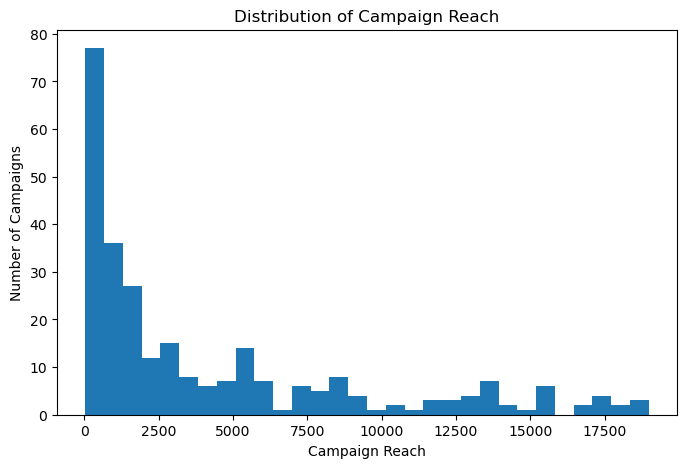

In [494]:
plt.figure(figsize=(8,5))
plt.hist(campaign_reach["campaign_reach"], bins=30)
plt.xlabel("Campaign Reach")
plt.ylabel("Number of Campaigns")
plt.title("Distribution of Campaign Reach")
plt.show()

##### Insights
- Vary substantially across campaigns
- Ranging from 31 to 18,987 recipients

## Historical engagement

In [224]:
# sort mailing id by timeline
df_history = df_final_topic.sort_values(['user_id', 'mailing_id']).copy()

In [225]:
# past cummulative opens (how many opens before this email?)
df_history['past_opens'] = (df_history.groupby('user_id')['open'].cumsum() - df_history['open'])

# past cummulative clicks (how many clicks before this email?)
df_history['past_clicks'] = (df_history.groupby('user_id')['click'].cumsum() - df_history['click'])

# cummulative email received before current email
df_history['emails_before'] = (df_history.groupby('user_id').cumcount())

In [226]:
# past open rate (average open rate for all email received before current one)
df_history['past_open_rate'] = (df_history['past_opens']/df_history['emails_before'])

# past click rate (average click rate for all email received before current one)
df_history['past_click_rate'] = (df_history['past_clicks']/df_history['emails_before'])

In [227]:
df_history[['user_id', 'emails_before', 'past_opens', 'past_clicks', 'past_open_rate', 'past_click_rate']].head()

,user_id,emails_before,past_opens,past_clicks,past_open_rate,past_click_rate
349935,5c6bebde5798a794283224c9,0,0.0,0.0,NaN,NaN
349936,5c6bebde5798a794283224c9,1,0.0,0.0,0.0,0.0
349937,5c6bebde5798a794283224c9,2,0.0,0.0,0.0,0.0
349938,5c6bebde5798a794283224c9,3,0.0,0.0,0.0,0.0
349939,5c6bebde5798a794283224c9,4,0.0,0.0,0.0,0.0


In [228]:
df_history['past_open_rate'].describe()

count    1.039581e+06
mean     5.558329e-01
std      3.447998e-01
min      0.000000e+00
25%      2.352941e-01
50%      6.000000e-01
75%      8.888889e-01
max      1.000000e+00
Name: past_open_rate, dtype: float64

In [229]:
print(df_history['past_click_rate'].describe())
print(df_history['past_click_rate'].quantile([0.9, 0.95, 0.99, 0.999]))

count    1.085029e+06
mean     1.438988e-03
std      2.447888e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: past_click_rate, dtype: float64
0.900    0.000000
0.950    0.000000
0.990    0.000000
0.999    0.384615
Name: past_click_rate, dtype: float64


##### Remark
Historical engagement estimates are less stable for users with limited piror exposure

### Historical opens

In [230]:
# create buckets for past open rate
df_history['past_open_bucket'] = pd.cut(
    df_history['past_open_rate'],
    bins = [0, 0.2, 0.4, 0.6, 0.8, 1],
    labels = [
        'very_low',
        'low',
        'medium',
        'high',
        'very_high'], include_lowest = True)

In [231]:
df_history['past_open_bucket'].value_counts(normalize = True)

past_open_bucket
very_high    0.340795
very_low     0.228470
high         0.156007
low          0.141542
medium       0.133186
Name: proportion, dtype: float64

In [232]:
# compare past open rates with current engagement rates
df_history.groupby('past_open_bucket')[['open', 'click']].mean()

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/3200546005.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_history.groupby('past_open_bucket')[['open', 'click']].mean()


,open,click
past_open_bucket,,
very_low,0.153234,0.001370
low,0.344941,0.001132
medium,0.499314,0.000809
high,0.635255,0.000887
very_high,0.841122,0.000997


In [233]:
# emails received before by each bucket
df_history.groupby('past_open_bucket')['emails_before'].mean()

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/1205713573.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_history.groupby('past_open_bucket')['emails_before'].mean()


past_open_bucket
very_low     28.828691
low          36.857351
medium       36.894076
high         36.818679
very_high    31.540812
Name: emails_before, dtype: float64

##### Insights
- Users with strong historical opens are substantially more likely to open future campaigns (this relationship is almost perfectly monotonic)
- Email open behaviour is persistent over time
- very_high users open more than 5 times as often as very_low users
- Historial open behaviour strongly influence future opens, but not necessarily influence future clicks
- Open buckets are not purely driven by exposure volume

### Historical clicks

In [234]:
# create binary groups for past click rates
df_history['clicked_before'] = (df_history['past_click_rate'] > 0)

In [235]:
df_history['clicked_before'].value_counts(normalize = True)

clicked_before
False    0.992415
True     0.007585
Name: proportion, dtype: float64

In [236]:
# compare past click rates with current engagement rates
df_history.groupby('clicked_before')[['open', 'click']].mean()

,open,click
clicked_before,,
False,0.537601,0.000177
True,0.355515,0.114126


In [237]:
# emails received before by each bucket
df_history.groupby('clicked_before')['emails_before'].mean()

clicked_before
False    32.185501
True     40.143085
Name: emails_before, dtype: float64

##### Insights
- Only 0.76% observations belong to users who had clicked before
- Users with any prior click history show substantially higher future clicks trend
- Prior clickers showed lower overall open rates -> more selective but action-oriented user segment
- Clickers tend to be more exposed to email campaigns but the difference is not huge so click effect is unlikely to be explained solely by exposure count

### Historical exposure

In [238]:
print(df_history['emails_before'].describe())
print(df_history['emails_before'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count    1.156304e+06
mean     3.224586e+01
std      2.142746e+01
min      0.000000e+00
25%      1.400000e+01
50%      3.000000e+01
75%      4.800000e+01
max      1.190000e+02
Name: emails_before, dtype: float64
0.10     5.0
0.25    14.0
0.50    30.0
0.75    48.0
0.90    62.0
0.95    70.0
0.99    85.0
Name: emails_before, dtype: float64


In [239]:
# create exposure buckets for number of emails received before 
df_history['exposure_bucket'] = pd.cut(
    df_history['emails_before'],
    bins = [0, 5, 15, 30, 50, 120],
    labels = [
        'very_little',
        'little',
        'moderate',
        'heavy',
        'very_heavy'], include_lowest = True)

In [240]:
df_history['exposure_bucket'].value_counts(normalize = True)

exposure_bucket
heavy          0.281815
moderate       0.230601
very_heavy     0.214039
little         0.169766
very_little    0.103779
Name: proportion, dtype: float64

In [241]:
# engagement rate
df_history.groupby('exposure_bucket')[['open', 'click']].mean()

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/1283421758.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_history.groupby('exposure_bucket')[['open', 'click']].mean()


,open,click
exposure_bucket,,
very_little,0.536223,0.002273
little,0.536522,0.001480
moderate,0.602338,0.000955
heavy,0.555333,0.000802
very_heavy,0.443650,0.000687


##### Insights
- Users with moderate prior exposure (15-30 previously received emails) showed highest open rates
- Very heavily exposed users showed lowest open rate -> email fatigue effect (inbox fatigue), repeated campaign exposure may reduce user response over time
- Click behaviour showed a stronger decline across exposure levels -> deeper email fatigue effect

### Historical opens x Historical exposure

In [242]:
df_history.groupby(['past_open_bucket', 'exposure_bucket'])[['open', 'click']].mean()

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/1373026044.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_history.groupby(['past_open_bucket', 'exposure_bucket'])[['open', 'click']].mean()


open     click
past_open_bucket exposure_bucket                    
very_low         very_little      0.156630  0.001121
                 little           0.124665  0.001380
                 moderate         0.201020  0.001253
                 heavy            0.160574  0.001638
                 very_heavy       0.107828  0.001353
low              very_little      0.385640  0.001357
                 little           0.346964  0.001783
                 moderate         0.423039  0.001291
                 heavy            0.369988  0.000670
                 very_heavy       0.240016  0.001145
medium           very_little      0.543620  0.003197
                 little           0.526742  0.001035
                 moderate         0.572150  0.000662
                 heavy            0.527139  0.000484
                 very_heavy       0.389597  0.000681
high             very_little      0.668643  0.003053
                 little           0.672864  0.001508
                 moderate         0.734665  0.000959
                 heavy            0.638846  0.000887
                 very_heavy       0.526360  0.000092
very_high        very_little      0.861024  0.003173
                 little           0.891092  0.001602
                 moderate         0.908792  0.000685
                 heavy            0.827836  0.000472
                 very_heavy       0.727193  0.000498

In [243]:
# pivot open rates
open_heatmap = df_history.pivot_table(
    values = 'open',
    index = 'past_open_bucket',
    columns = 'exposure_bucket',
    aggfunc = 'mean')

open_heatmap


/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/778025394.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  open_heatmap = df_history.pivot_table(


exposure_bucket,very_little,little,moderate,heavy,very_heavy
past_open_bucket,,,,,
very_low,0.156630,0.124665,0.201020,0.160574,0.107828
low,0.385640,0.346964,0.423039,0.369988,0.240016
medium,0.543620,0.526742,0.572150,0.527139,0.389597
high,0.668643,0.672864,0.734665,0.638846,0.526360
very_high,0.861024,0.891092,0.908792,0.827836,0.727193


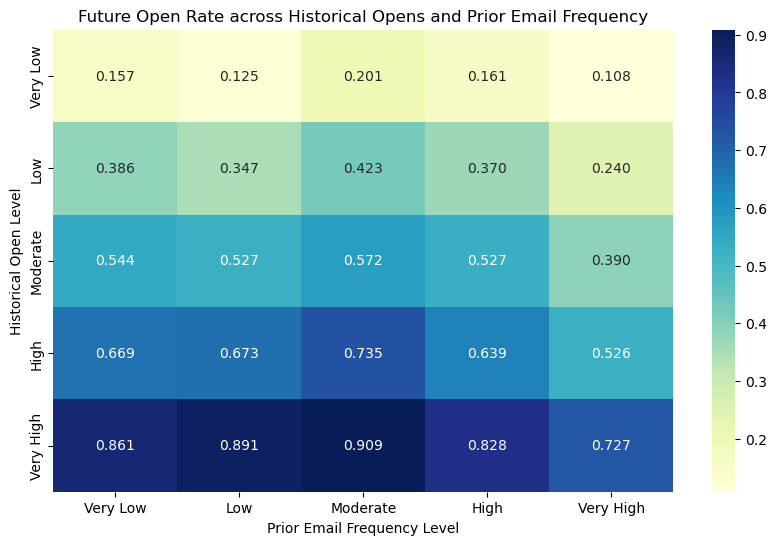

In [244]:
# heat map

#relabel rows and columns
open_heatmap = open_heatmap.rename(
    index = {
        'very_low': 'Very Low',
        'low': 'Low',
        'medium': 'Moderate',
        'high': 'High',
        'very_high': 'Very High'},

    columns = {
        'very_little': 'Very Low',
        'little': 'Low',
        'moderate': 'Moderate',
        'heavy': 'High',
        'very_heavy': 'Very High'})

# plot
plt.figure(figsize = (10,6))

sns.heatmap(
    open_heatmap,
    annot = True,
    fmt = ".3f",
    cmap = "YlGnBu"
)

plt.title('Future Open Rate across Historical Opens and Prior Email Frequency')
plt.ylabel('Historical Open Level')
plt.xlabel('Prior Email Frequency Level')

plt.show()

##### Insights
- Past open behaviour is a very strong predictor of future opens (just like in earlier finding)
- Moderate exposure may reinforce engagement rather than immediately causing fatigue (just like in earlier finding)
- Extreme frequent exposure is associated with declining engagement, even among historically active users
- Highly historically engaged users appear more resistant to exposure fatigue

### Historical clicks x Historical exposure

In [245]:
df_history.groupby(['exposure_bucket', 'clicked_before'])[['open', 'click']].mean()

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/972640059.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_history.groupby(['exposure_bucket', 'clicked_before'])[['open', 'click']].mean()


open     click
exposure_bucket clicked_before                    
very_little     False           0.535939  0.000765
                True            0.646209  0.559486
little          False           0.537155  0.000187
                True            0.419558  0.234390
moderate        False           0.604427  0.000095
                True            0.333512  0.110110
heavy           False           0.556988  0.000097
                True            0.346335  0.087859
very_heavy      False           0.445065  0.000074
                True            0.327556  0.049023

In [246]:
# pivot click rates
click_pivot = df_history.pivot_table(
    values = 'click',
    index = 'exposure_bucket',
    columns = 'clicked_before',
    aggfunc = 'mean')

click_pivot

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/1262622633.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  click_pivot = df_history.pivot_table(


clicked_before,False,True
exposure_bucket,,
very_little,0.000765,0.559486
little,0.000187,0.234390
moderate,0.000095,0.110110
heavy,0.000097,0.087859
very_heavy,0.000074,0.049023


In [247]:
interaction_plot_click = (df_history.groupby(['exposure_bucket', 'clicked_before'])[['click']].mean().reset_index())

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/578257432.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interaction_plot_click = (df_history.groupby(['exposure_bucket', 'clicked_before'])[['click']].mean().reset_index())


/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/3193063554.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  interaction_plot_click['exposure_bucket'] = interaction_plot_click['exposure_bucket'].replace({


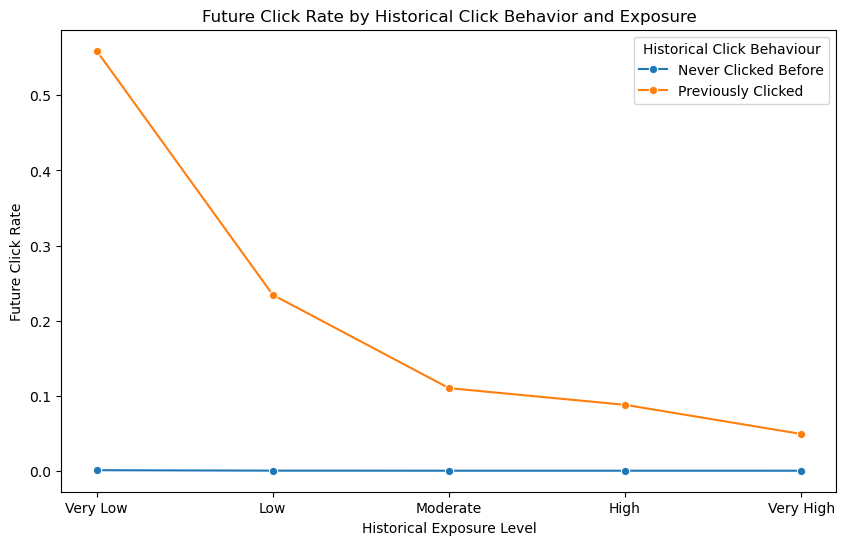

In [248]:
# line plot

# relabel x axis
interaction_plot_click['exposure_bucket'] = interaction_plot_click['exposure_bucket'].replace({
    'very_little': 'Very Low',
    'little': 'Low',
    'moderate': 'Moderate',
    'heavy': 'High',
    'very_heavy': 'Very High'})

# relabel hue
interaction_plot_click['clicked_before'] = interaction_plot_click['clicked_before'].replace({
    True: 'Previously Clicked',
    False: 'Never Clicked Before'})

#plot
plt.figure(figsize=(10,6))

sns.lineplot(
    data=interaction_plot_click,
    x='exposure_bucket',
    y='click',
    hue='clicked_before',
    marker='o'
)

plt.title('Future Click Rate by Historical Click Behavior and Exposure')
plt.xlabel('Historical Exposure Level')
plt.ylabel('Future Click Rate')

plt.legend(title = 'Historical Click Behaviour')

plt.show()

##### Insights
- Exposure barely changes anything for users who never clicked before
- Historically engaged clickers are highly sensitive to exposure volume
- Exposure redically compress click behaviour among prior clickers

In [249]:
# pivot open rates
open_pivot = df_history.pivot_table(
    values = 'open',
    index = 'exposure_bucket',
    columns = 'clicked_before',
    aggfunc = 'mean')

open_pivot

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/2458622972.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  open_pivot = df_history.pivot_table(


clicked_before,False,True
exposure_bucket,,
very_little,0.535939,0.646209
little,0.537155,0.419558
moderate,0.604427,0.333512
heavy,0.556988,0.346335
very_heavy,0.445065,0.327556


In [250]:
interaction_plot_open = (df_history.groupby(['exposure_bucket', 'clicked_before'])[['open']].mean().reset_index())

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/3682317467.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interaction_plot_open = (df_history.groupby(['exposure_bucket', 'clicked_before'])[['open']].mean().reset_index())


/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/168898132.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  interaction_plot_open['exposure_bucket'] = interaction_plot_open['exposure_bucket'].replace({


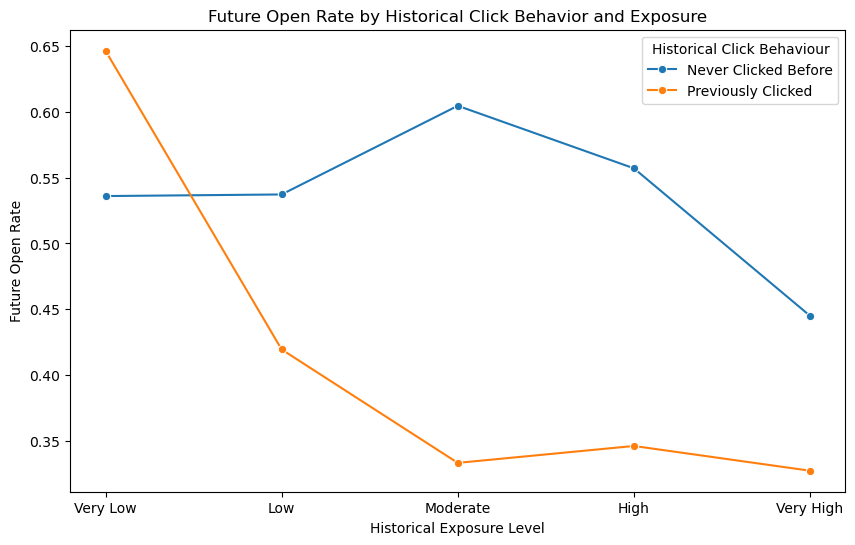

In [251]:
# line plot

# relabel x axis
interaction_plot_open['exposure_bucket'] = interaction_plot_open['exposure_bucket'].replace({
    'very_little': 'Very Low',
    'little': 'Low',
    'moderate': 'Moderate',
    'heavy': 'High',
    'very_heavy': 'Very High'})

# relabel hue
interaction_plot_open['clicked_before'] = interaction_plot_open['clicked_before'].replace({
    True: 'Previously Clicked',
    False: 'Never Clicked Before'})

#plot
plt.figure(figsize=(10,6))

sns.lineplot(
    data=interaction_plot_open,
    x='exposure_bucket',
    y='open',
    hue='clicked_before',
    marker='o'
)

plt.title('Future Open Rate by Historical Click Behavior and Exposure')
plt.xlabel('Historical Exposure Level')
plt.ylabel('Future Open Rate')

plt.legend(title = 'Historical Click Behaviour')


plt.show()

##### Insights
- Similar but weaker pattern was observed for future opens
- Exposure affects prior clickers much more strongly than historically passive users
- Prior clickers showed substantially lower open rates under heavier exposure levels

### Historical opens x Historical clicks

In [252]:
df_history.groupby(['past_open_bucket', 'clicked_before'])[['open', 'click']].mean()

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/2823338909.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_history.groupby(['past_open_bucket', 'clicked_before'])[['open', 'click']].mean()


open     click
past_open_bucket clicked_before                    
very_low         False           0.153576  0.000331
                 True            0.120295  0.093699
low              False           0.346328  0.000066
                 True            0.234521  0.081096
medium           False           0.500872  0.000098
                 True            0.351145  0.065926
high             False           0.636007  0.000083
                 True            0.525408  0.115245
very_high        False           0.841359  0.000125
                 True            0.783032  0.208623

In [253]:
# create binary open groups (high/low past opens)
df_history['open_behaviour'] = np.where(
    df_history['past_open_rate'] >= df_history['past_open_rate'].median(),      # median as threshold
    'High Historical Opens',
    'Low Historical Opens')

In [254]:
df_history['open_behaviour'].value_counts(normalize = True)

open_behaviour
Low Historical Opens     0.547731
High Historical Opens    0.452269
Name: proportion, dtype: float64

In [255]:
# create behavioural groups based on open groups and click groups
conditions = [
    (df_history['open_behaviour'] == 'High Historical Opens') &
    (df_history['clicked_before'] == False),

    (df_history['open_behaviour'] == 'High Historical Opens') &
    (df_history['clicked_before'] == True),

    (df_history['open_behaviour'] == 'Low Historical Opens') &
    (df_history['clicked_before'] == False),

    (df_history['open_behaviour'] == 'Low Historical Opens') &
    (df_history['clicked_before'] == True)]

# group names
choices = [
    'Habitual Openers',         # high past opens, never clicked
    'Highly Engaged Users',     # high past opens, clicked before
    'Disengaged Users',         # low past opens, never clicked
    'Selective Users']          # low past opens, clicked before

df_history['engagement_group'] = np.select(conditions, choices, default = 'Other')

In [256]:
df_history.groupby('engagement_group')[['open', 'click']].mean().sort_values('click', ascending = False)

,open,click
engagement_group,,
Highly Engaged Users,0.665898,0.167243
Selective Users,0.212604,0.091734
Disengaged Users,0.304201,0.000232
Habitual Openers,0.774846,0.000113


In [257]:
df_history['engagement_group'].value_counts(normalize = True)

engagement_group
Disengaged Users        0.542395
Habitual Openers        0.450020
Selective Users         0.005336
Highly Engaged Users    0.002249
Name: proportion, dtype: float64

## Click-given-open Analysis

In [258]:
# keep only emails that were open
df_opened = df_history[df_history['open'] == 1].copy()

#click rate a mong opened emails
overall_click_given_open = df_opened['click'].mean()

overall_click_given_open

0.001574200601257174

In [259]:
df_opened.shape

(567034, 31)

##### Insights
Open rate ~50-60%, but post-open conversion is extremely low -> attention does not necessarily translate into deeper engagement

### Click-given-open by topic

In [260]:
# click|open by topic
df_opened.groupby('main_topic')['click'].mean().sort_values(ascending = False)

main_topic
Charity & Social Impact    0.004264
Finance & Investment       0.002640
Automotive & Mobility      0.002490
Retail & Promotion         0.001462
Business                   0.001461
Lottery & Games            0.001419
Missing                    0.000843
Media & Publishing         0.000786
Energy & Sustainability    0.000643
Health & Wellbeing         0.000169
Food & Beverages           0.000137
Telecom & Technology       0.000000
Name: click, dtype: float64

In [261]:
df_opened['main_topic'].value_counts()

main_topic
Media & Publishing         233359
Automotive & Mobility      147846
Lottery & Games             60136
Charity & Social Impact     43435
Energy & Sustainability     25817
Health & Wellbeing          12053
Business                    10793
Retail & Promotion          10571
Missing                      9828
Food & Beverages             7629
Finance & Investment         4902
Telecom & Technology          665
Name: count, dtype: int64

In [262]:
df_opened['main_topic'].value_counts(normalize = True)

main_topic
Media & Publishing         0.411543
Automotive & Mobility      0.260736
Lottery & Games            0.106054
Charity & Social Impact    0.076600
Energy & Sustainability    0.045530
Health & Wellbeing         0.021256
Business                   0.019034
Retail & Promotion         0.018643
Missing                    0.017332
Food & Beverages           0.013454
Finance & Investment       0.008645
Telecom & Technology       0.001173
Name: proportion, dtype: float64

##### Insights
- Charity & Social, Finance & Investment , Automotive & Mobility: highest post-open conversion rates -> these topics generate stronger action-oriented engagement
- Charity & Social, Finance & Investment: strong post-open behaviour despite low exposure volume
- Health & Wellbeing, Food & Beverages: weak post-open conversion 
- Topic distributions are highly imbalanced (Media & Publishing and Automotive & Mobility account for the majority of opened emails)
- Engagement rates for dominant topics are more stable, smaller topics (eg. Telecom & Technology) should be interpreted more cautiously

### Click-given-open by historical engagement

In [263]:
# click|open by historical engagement
df_opened.groupby('past_open_bucket')['click'].mean()

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/4276582021.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_opened.groupby('past_open_bucket')['click'].mean()


past_open_bucket
very_low     0.005118
low          0.002486
medium       0.001478
high         0.001137
very_high    0.001133
Name: click, dtype: float64

In [264]:
df_opened['past_open_bucket'].value_counts(normalize = True)

past_open_bucket
very_high    0.534706
high         0.184865
medium       0.124050
low          0.091074
very_low     0.065305
Name: proportion, dtype: float64

##### Insights
- Historically frequent openers are LESS likely to click after opening (open frequently, low click intent) -> high opens does not necessarily imply high clicks
- Low historical open users are MORE likely to click (open rarely, higher click intent)
- Strongest click-given-open users are a minority segment (users with very low past open rates)
- Past open negatively relates to post-open clicking, past open strongly related to future opens (earlier findings) -> opens and clicks represent different dimensions of engagement

### Click-given-open by exposure bucket

In [265]:
# click|open by exposure bucket
df_opened.groupby('exposure_bucket')['click'].mean()

/var/folders/kz/wylm8_ks1d7bmsgm23zfsgh80000gn/T/ipykernel_72830/1598103630.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_opened.groupby('exposure_bucket')['click'].mean()


exposure_bucket
very_little    0.003278
little         0.002029
moderate       0.001189
heavy          0.001170
very_heavy     0.001387
Name: click, dtype: float64

In [266]:
df_opened['exposure_bucket'].value_counts(normalize = True)

exposure_bucket
heavy          0.290810
moderate       0.256457
very_heavy     0.183696
little         0.167115
very_little    0.101922
Name: proportion, dtype: float64

##### Insights
- Post-open conversion behaviour generally declines as historical email exposure increases, with a slight increase among the heaviest exposured users (may suggest content fatigue)
- Users with lower historical exposure are more likely to click after opening
- Heavily exposed users show weaker post-open engagement -> repeated campaign exposre may reduce not only initial attention (earlier finding) but also deeper engagement

### Click-given-open by interest match

In [267]:
df_opened.columns

Index(['user_id', 'gender', 'birth_date', 'postcode', 'city', 'interests',
       'age', 'n_interests', 'open_type', 'click_type', 'mailing_id', 'open',
       'click', 'mailing_info', 'subject_line', 'preheader', 'main_topic',
       'open_segment', 'click_segment', 'mapped_interest_topic',
       'interest_topic_match', 'past_opens', 'past_clicks', 'emails_before',
       'past_open_rate', 'past_click_rate', 'past_open_bucket',
       'clicked_before', 'exposure_bucket', 'open_behaviour',
       'engagement_group'],
      dtype='object')

In [268]:
# click|open by interest match
df_opened.groupby('interest_topic_match')['click'].mean()

interest_topic_match
0    0.001828
1    0.001562
Name: click, dtype: float64

In [269]:
df_opened['interest_topic_match'].value_counts(normalize = True)

interest_topic_match
1    0.92259
0    0.07741
Name: proportion, dtype: float64

##### Insights
- Most opened emails were classified as matching user interests (~92%), however, matched emails did not achieve higher click-given-open rates
-> Interest matching mainly influenes opens rather than post-open engagement

## Temporal Analysis

### Data Preparation

In [456]:
# load new dataset
df_extra_raw = pd.read_excel('UVA Robin .xlsx',sheet_name = 0)

In [457]:
df_extra_raw.head()

,Unnamed: 0,Subjectline,Mail ID,Dag,Datum,Klant / bureau,Campagnenaam,Time stamp,openInterst / clickInterest,Mail content,Unnamed: 10
0,ntvx,NaN,1417,Donderdag,2026-04-23 00:00:00,CPX,Donald Duck + Strandpakket,-Akkoord,"bladen, cadeaux",NaN,NaN
1,NaN,Wat zit er in Donalds strandtas?,NaN,NaN,NaN,NaN,NaN,Subjectline: Wat zit er in Donalds strandtas?,NaN,https://mail.omg.nl/x/?S7Y1.J9ra2hiaPm.CMjMyU_...,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pre-header: Ontdek het pakket en lees de leuks...,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,260422 - CPX - CPX Donald Duck + Strandpakket ...,NaN,NaN,NaN
4,ntvx,NaN,1418,Donderdag,2026-04-23 00:00:00,CRS,Donald Duck + Strandpakket,-Akkoord,"bladen, cadeaux",https://mail.omg.nl/x/?S7Y1.J9ra2hiaPm.CMjMyU_...,NaN


In [458]:
# strip column names
df_extra = df_extra_raw.copy()
df_extra.columns = df_extra.columns.str.strip()

# remove week separator rows
df_extra = df_extra[
    ~df_extra['Unnamed: 0']
    .astype(str)
    .str.contains('WK', case = False, na = False)].copy()

# find block starting row (ntvx)
is_ntvx = (
    df_extra["Unnamed: 0"]
    .astype(str)
    .str.lower()
    .eq("ntvx")
)

is_header_like = (
    df_extra["Mail ID"].astype(str).str.lower().eq("x")
    & df_extra["Dag"].notna()
    & df_extra["Datum"].notna()
    & df_extra["Campagnenaam"].notna()
)

df_extra["is_new_mailing"] = is_ntvx | is_header_like

# assign block id to each block
df_extra['block_id'] = df_extra['is_new_mailing'].cumsum()

# remove anything before first ntvx
df_extra = df_extra[df_extra['block_id'] > 0].copy()

In [459]:
def first_valid(s):
    s = s.dropna()
    return s.iloc[0] if len(s) > 0 else pd.NA

def extract_all_ids(s):
    ids = []

    for value in s.dropna().astype(str):
        value = value.strip().lower()

        if value in ["x", "#n/a", "nan"]:
            continue

        found = re.findall(r"\b\d{3,5}\b", value)

        for item in found:
            ids.append(int(item))

    return list(dict.fromkeys(ids))

In [460]:
extra_clean = (
    df_extra.groupby("block_id").agg({
        "Mail ID": extract_all_ids,
        "Dag": first_valid,
        "Datum": first_valid,
        "Klant / bureau": first_valid,
        "Campagnenaam": first_valid,
        "Subjectline": first_valid,
        "Time stamp": lambda x: " | ".join(x.dropna().astype(str))
    }).reset_index())

In [461]:
extra_clean["n_mail_ids"] = extra_clean["Mail ID"].apply(len)

extra_clean["id_status"] = extra_clean["n_mail_ids"].map({
    0: "no_id",
    1: "single_id"
}).fillna("multiple_ids")

extra_clean["mailing_id_clean"] = extra_clean["Mail ID"].apply(
    lambda x: x[0] if len(x) == 1 else pd.NA
)

In [462]:
extra_clean["id_status"].value_counts()

id_status
single_id       219
no_id            74
multiple_ids     20
Name: count, dtype: int64

In [463]:
extra_clean.loc[
    extra_clean["id_status"] == "multiple_ids",
    ["block_id", "Mail ID", "Subjectline", "Campagnenaam"]
].head(20)

,block_id,Mail ID,Subjectline,Campagnenaam
7,8,"[1402, 1403]",Weet jij hoelang je het uithoudt zonder inkomen?,Centraal Beheer - EDM AOV - Subjectlinetest
26,27,"[1354, 1348]",Ontdek de ruime en verfijnde Mazda CX-6e,Mazda Zakelijk - Subjectlinetest
47,48,"[1274, 1301]",Wat levert jouw auto op tijdens het Mazda Taxa...,Mazda particulier - Subjectlinetest
61,62,"[1248, 1251]",update HR wet- en regelgeving 2026.,Randstad - HR campagne - Subjectlinetest
80,81,"[1148, 1119]",Slim zakelijk rijden? Ontdek de Mazda6e,Mazda MKB - subjectlinetest
86,87,"[1090, 1107]",Elektrisch rijden met verfijning: ontdek de Ma...,Mazda Zakelijk - subjectlinetest
111,112,"[1031, 1013]",Maak kans op de hoofdprijs van €1.000.000,Staatslotterij - Subjectlinetest
112,113,"[1022, 1016]",Tijdelijk tot €4.000 inruilvoordeel bij Mazda,Mazda Particulieren - subjectlinetest
145,146,"[927, 928, 929]","Voornaam, word en blijf een aantrekkelijke wer...",Randstad - subjectline test
152,153,"[922, 908]",Stap in voor een proefrit met de Mazda6e,Mazda MKB - subjectlinetest


In [464]:
no_id_blocks = extra_clean[
    extra_clean["id_status"] == "no_id"
].copy()

In [466]:
no_id_blocks[
    ["block_id",
     "Subjectline",
     "Campagnenaam",
     "Time stamp"]
].head()

,block_id,Subjectline,Campagnenaam,Time stamp
85,86,Dit kan jouw bedrijf ook met 5G en IoT,Odido - Reminder opens,-Akkoord | Subjectline: Dit kan jouw bedrijf o...
120,121,<NA>,Belife - Reminder non clicks,- Akkoord | Onderwerp:​ Mentaal sterker worden...
126,127,<NA>,Odido - uitrol,- | Pre-header: | Pre-header:
239,240,Jouw zomer vol fietsroutes en boerderijverhalen,Landleven - special,-Akkoord | Subjectline: Jouw zomer vol fietsro...
242,243,Exclusieve aanbieding: jouw krant 4 weken voor...,DPG - 4 weken 4 euro,- Akkoord | Subjectline: Exclusieve aanbieding...


In [467]:
# keep only rows with at least one usable ID
extra_schedule = extra_clean[
    extra_clean["id_status"].isin(["single_id", "multiple_ids"])
].copy()

# expand multiple IDs into one row per mailing ID
extra_schedule = extra_schedule.explode("Mail ID").reset_index(drop=True)

# rename and clean
extra_schedule = extra_schedule.rename(columns={
    "Mail ID": "mailing_id",
    "Dag": "send_day_of_week",
    "Datum": "send_date",
    "Time stamp": "timestamp_raw"
})

extra_schedule["mailing_id"] = extra_schedule["mailing_id"].astype(int)

# keep only the fields we actually trust/use from this file
extra_schedule = extra_schedule[
    [
        "mailing_id",
        "send_day_of_week",
        "send_date",
        "timestamp_raw",
        "block_id",
        "id_status"
    ]
].copy()

In [468]:
extra_schedule.head()

,mailing_id,send_day_of_week,send_date,timestamp_raw,block_id,id_status
0,1417,Donderdag,2026-04-23 00:00:00,-Akkoord | Subjectline: Wat zit er in Donalds ...,1,single_id
1,1418,Donderdag,2026-04-23 00:00:00,-Akkoord | Subjectline: Wat zit er in Donalds ...,2,single_id
2,1419,Donderdag,2026-04-23 00:00:00,-Akkoord | Subjectline: Wat zit er in Donalds ...,3,single_id
3,1411,Dinsdag,2026-04-21 00:00:00,- Akkoord | Subjectline: Weet jij hoelang je h...,4,single_id
4,1408,Donderdag,2026-04-16 00:00:00,- Akkoord | Subjectline: Weet jij hoelang je h...,5,single_id


In [472]:
extra_schedule["mailing_id"].nunique(), len(extra_schedule)


(206, 260)

In [473]:
extra_schedule["mailing_id"].duplicated().sum()

54

In [474]:
extra_schedule[
    extra_schedule["mailing_id"].duplicated(keep=False)
].sort_values("mailing_id")

,mailing_id,send_day_of_week,send_date,timestamp_raw,block_id,id_status
259,641,Donderdag,2025-03-27 00:00:00,-Akkoord | Subjectline: Maak een proefrit in d...,255,multiple_ids
257,641,Donderdag,2025-04-03 00:00:00,-Akkoord | Subjectline: Win een reis naar Japa...,242,single_id
256,646,Dinsdag,2025-04-08 00:00:00,-Akkoord | Subjectline:Jouw proefrit in de Maz...,241,single_id
258,646,Donderdag,2025-03-27 00:00:00,-Akkoord | Subjectline: Maak een proefrit in d...,255,multiple_ids
243,706,Dinsdag,2025-05-06 00:00:00,- Akkoord | Subjectline: Zo werkt Tikkie zake...,227,single_id
...,...,...,...,...,...,...
36,1355,Maandag,2026-02-23 00:00:00,- Akkoord | Subjectline: NS Zakelijk maakt mob...,35,single_id
30,1389,Dinsdag,2026-03-17 00:00:00,- Akkoord | Subjectline: Maak kans op een Tenw...,29,single_id
11,1389,Woensdag,2026-04-08 00:00:00,- Akkoord | Subjectline: Maak kans op een Tenw...,11,single_id
47,1399,Donderdag,2026-02-12 00:00:00,- Akkoord | Subjectline: MAX Magazine én een H...,46,single_id


In [475]:
dup_summary = (
    extra_schedule
    .groupby("mailing_id")
    .agg(
        n_rows=("mailing_id", "size"),
        n_dates=("send_date", "nunique"),
        dates=("send_date", lambda x: sorted(x.dropna().astype(str).unique())),
        statuses=("id_status", lambda x: sorted(x.dropna().astype(str).unique()))
    )
    .reset_index()
)

dup_summary["date_status"] = dup_summary["n_dates"].map({
    0: "no_date",
    1: "one_date"
}).fillna("conflicting_dates")

dup_summary["date_status"].value_counts()

date_status
one_date             166
conflicting_dates     40
Name: count, dtype: int64

In [480]:
# keep only mailing_ids with exactly one date
trusted_ids = dup_summary.loc[
    dup_summary["date_status"] == "one_date",
    "mailing_id"
]

extra_schedule_trusted = extra_schedule[
    extra_schedule["mailing_id"].isin(trusted_ids)
].copy()

# one row per mailing_id
extra_schedule_trusted = (
    extra_schedule_trusted
    .sort_values(["mailing_id", "send_date"])
    .drop_duplicates(subset=["mailing_id"], keep="first")
    .copy()
)

extra_schedule_trusted.shape

(166, 6)

In [481]:
df_final_topic_time = df_final_topic.merge(
    extra_schedule_trusted[[
        "mailing_id",
        "send_day_of_week",
        "send_date",
        "timestamp_raw"
    ]],
    on="mailing_id",
    how="left"
)

In [485]:
print(df_final_topic_time["send_date"].notna().mean())
print(df_final_topic_time.groupby("mailing_id")["send_date"].first().notna().mean())
print(df_final_topic_time["send_date"].isna().value_counts())

0.673301311765764
0.551094890510949
send_date
False    778541
True     377763
Name: count, dtype: int64


##### Insights
After cleaning, excluding records without reliable mailing IDS or with conflicting sending dates:
- 67.3% recipient-campaign rows have sending date
- 55.1% of campaigns (mailing IDS) have sending date

### Historical Order Validation

In [486]:
# campaign-level dated subset
campaign_dates = (
    df_final_topic_time
    .dropna(subset=["send_date"])
    .groupby("mailing_id")["send_date"]
    .first()
    .reset_index()
)

campaign_dates["send_date"] = pd.to_datetime(campaign_dates["send_date"])

campaign_dates = campaign_dates.sort_values("mailing_id").copy()

In [487]:
campaign_dates[["mailing_id", "send_date"]].head(20)
campaign_dates[["mailing_id", "send_date"]].tail(20)

,mailing_id,send_date
131,1343,2026-03-15
132,1345,2026-03-19
133,1348,2026-03-17
134,1350,2026-03-19
135,1361,2026-03-24
136,1362,2026-03-24
137,1363,2026-03-24
138,1365,2026-04-07
139,1378,2026-04-01
140,1379,2026-04-01


In [488]:
campaign_dates["date_rank"] = campaign_dates["send_date"].rank(method="dense")

campaign_dates[["mailing_id", "date_rank"]].corr(method="spearman")

,mailing_id,date_rank
mailing_id,1.000000,0.998661
date_rank,0.998661,1.000000


In [489]:
campaign_dates["previous_date"] = campaign_dates["send_date"].shift(1)

campaign_dates["date_goes_backward"] = (
    campaign_dates["send_date"] < campaign_dates["previous_date"]
)

campaign_dates["date_goes_backward"].mean()

0.17218543046357615